[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/comptelab/BIORTC_Nigeria/blob/main/2026/Projects/DL_for_Seizure_Detection_in_EEG.ipynb)

# EEG Project 1: Seizure Detection - ML vs DL
### BioRTC 2026 · Simons Computational Neuroscience Programme · Yobe State University

---

This notebook builds two automated seizure detectors on the **TUH EEG Seizure Corpus (TUSZ v2.0.6)** and compares them:

| Model | Input | Feature extraction |
|---|---|---|
| **MLP** (multilayer perceptron) | Band-power features | Handcrafted (you designed these in EEG_01) |
| **1D-CNN** | Raw EEG signal | Learned automatically by the network |

The central question is: **does preprocessing the signal (filtering + ICA) actually help, or can a deep learning model learn to ignore artifacts on its own?**

**Contents**
1. Load & explore a TUSZ recording
2. Windowing & seizure labels
3. Model A - MLP on band-power features
4. Model B - 1D-CNN on raw signal
5. Does preprocessing help?
6. The online challenge - evaluating as if deployed
7. Generalization - a different patient

In [1]:
# Install missing packages when running on Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q mne

In [2]:
# Download the required TUSZ recordings from the course GitHub repo when running on Google Colab
if IN_COLAB:
    import os, urllib.request

    BASE_URL = 'https://raw.githubusercontent.com/comptelab/BIORTC_Nigeria/main/2026/Data/TUH_EEG_Corpus/TUSZ/v2.0.6/edf/dev'
    RECORDINGS = [
        ('aaaaasgd', 's001_2015', 'aaaaasgd_s001_t000'),   # demo + training
        ('aaaaampk', 's007_2012', 'aaaaampk_s007_t001'),   # training
        ('aaaaaoys', 's002_2013', 'aaaaaoys_s002_t004'),   # training
        ('aaaaamnd', 's007_2012', 'aaaaamnd_s007_t003'),   # held-out generalization
    ]

    for patient, session, bname in RECORDINGS:
        rel_dir   = f'{patient}/{session}/01_tcp_ar'
        local_dir = os.path.join('TUH_EEG_Corpus/TUSZ/v2.0.6/edf/dev', rel_dir)
        os.makedirs(local_dir, exist_ok=True)
        for ext in ['.edf', '.csv']:
            local_path = os.path.join(local_dir, bname + ext)
            if not os.path.exists(local_path):
                urllib.request.urlretrieve(f'{BASE_URL}/{rel_dir}/{bname}{ext}', local_path)
            print(f'{"OK  " if os.path.exists(local_path) else "MISS"} {local_path}')

    # Section 8: the real YSUTH (Yobe) recording, header-anonymized, no labels
    YSUTH_URL = 'https://raw.githubusercontent.com/comptelab/BIORTC_Nigeria/main/2026/Data/YSUTH/SUBJECT1.edf'
    os.makedirs('YSUTH', exist_ok=True)
    ysuth_path = os.path.join('YSUTH', 'SUBJECT1.edf')
    if not os.path.exists(ysuth_path):
        urllib.request.urlretrieve(YSUTH_URL, ysuth_path)
    print(f'{"OK  " if os.path.exists(ysuth_path) else "MISS"} {ysuth_path}')

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mne
from scipy import signal as sp
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

PyTorch 2.10.0  |  device: cpu


---
## Configuration

All paths and hyperparameters live here. Change `BNAME` to try a different recording.

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TUSZ_ROOT = 'TUH_EEG_Corpus/TUSZ/v2.0.6/edf'
MONTAGE   = '01_tcp_ar'

# ── Demo recording ─────────────────────────────────────────────────────────────
# Patient aaaaasgd, session 1, token 0: 30 min, 256 Hz, three focal seizures
# Seizure 1: ~322 s (training)  Seizure 2: ~1042 s (training)  Seizure 3: ~1467 s (test)
PATIENT   = 'aaaaasgd'
SESSION   = 's001_2015'
BNAME     = 'aaaaasgd_s001_t000'

EDF_PATH  = os.path.join(TUSZ_ROOT, 'dev', PATIENT, SESSION, MONTAGE, BNAME + '.edf')
CSV_PATH  = os.path.join(TUSZ_ROOT, 'dev', PATIENT, SESSION, MONTAGE, BNAME + '.csv')

# ── Windowing ─────────────────────────────────────────────────────────────────
WIN_S   = 4.0   # window length in seconds
HOP_S   = 2.0   # hop size in seconds (50% overlap)
THRESH  = 0.5   # fraction of window that must be seizure to label it 1

# ── Frequency bands (same as EEG_01) ──────────────────────────────────────────
BANDS = {'delta': (0.5, 4), 'theta': (4, 8),
         'alpha': (8, 12),  'beta':  (13, 30), 'gamma': (30, 45)}

# ── Training ──────────────────────────────────────────────────────────────────
SEED      = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'EDF : {EDF_PATH}')
print(f'Found: {os.path.exists(EDF_PATH)}')

EDF : TUH_EEG_Corpus/TUSZ/v2.0.6/edf/dev/aaaaasgd/s001_2015/01_tcp_ar/aaaaasgd_s001_t000.edf
Found: True


---
## Section 1 - Load & Explore the Recording

TUSZ v2.0.6 uses the same file format as TUAR (EDF + CSV), with one difference: the CSV **has a header row** and the time columns are named `start_time` / `stop_time` instead of `start` / `stop`. See the corpus overview in EEG_01 for the full format description.

The folder structure also adds patient and session levels:
```
tusz/v2.0.6/edf/
├── train/  ← used to train published models
├── dev/    ← used during development (what we use here)
└── eval/   ← held-out test set, used for published benchmarks
    └── [patient_id]/[session_year]/[01_tcp_ar|02_tcp_le]/[bname].edf
```

In [5]:
raw = mne.io.read_raw_edf(EDF_PATH, preload=True)
sfreq    = raw.info['sfreq']
duration = raw.times[-1]
n_ch     = len(raw.ch_names)

print(f'Channels     : {n_ch}')
print(f'Sampling rate: {sfreq} Hz')
print(f'Duration     : {duration:.0f} s  ({duration/60:.1f} min)')
print()
print('Channel names:')
print(raw.ch_names)

Channels     : 34
Sampling rate: 256.0 Hz
Duration     : 1800 s  (30.0 min)

Channel names:
['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG T1-REF', 'EEG T2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF', 'EEG EKG1-REF', 'EEG LOC-REF', 'EEG ROC-REF', 'EEG SP1-REF', 'EEG SP2-REF', 'EMG-REF', 'EEG A1-REF', 'EEG A2-REF', 'EEG 31-REF', 'EEG 32-REF', 'IBI', 'BURSTS', 'SUPPR']


In [6]:
def read_tusz_csv(path):
    """Read a TUSZ annotation CSV (has a header row, unlike TUAR)."""
    df = pd.read_csv(path, comment='#')
    df = df.rename(columns={'start_time': 'start', 'stop_time': 'stop'})
    df['start'] = pd.to_numeric(df['start'], errors='coerce')
    df['stop']  = pd.to_numeric(df['stop'],  errors='coerce')
    return df.dropna(subset=['start', 'stop'])


def merge_seizure_intervals(seiz_df, gap_s=5.0):
    """
    Merge seizure annotations across all channels into one set of intervals.

    TUSZ annotates each channel separately with potentially different onset/offset
    times.  Filtering by a single channel misses seizures that only appear on other
    channels (common in focal seizures).  We sort all non-background rows by start
    time and merge events that are within gap_s of each other.
    """
    seiz_all = (seiz_df[seiz_df['label'] != 'bckg']
                .sort_values('start').reset_index(drop=True))
    merged = []
    for _, r in seiz_all.iterrows():
        if not merged or float(r['start']) > merged[-1]['stop'] + gap_s:
            merged.append({'start': float(r['start']),
                           'stop':  float(r['stop']),
                           'label': r['label']})
        else:
            merged[-1]['stop'] = max(merged[-1]['stop'], float(r['stop']))
    cols = ['start', 'stop', 'label']
    return pd.DataFrame(merged, columns=cols) if merged else pd.DataFrame(columns=cols)


seiz_df = read_tusz_csv(CSV_PATH)

# Show the first-channel annotations (relevant for Q4 — bipolar vs referential mismatch)
ch0 = seiz_df['channel'].iloc[0]
seiz_ch0 = seiz_df[seiz_df['channel'] == ch0].copy()
print(f'Annotations for channel {ch0} only:')
print(seiz_ch0[['start', 'stop', 'label']].to_string(index=False))
print()

# Extract seizure intervals using the union across all channels
seiz_intervals = merge_seizure_intervals(seiz_df)
print('Seizure intervals (merged across all channels):')
for _, r in seiz_intervals.iterrows():
    print(f"  {r['label']}  {r['start']:.0f}s – {r['stop']:.0f}s  ({r['stop']-r['start']:.0f}s)")

Annotations for channel F7-T3 only:
   start     stop label
340.0175 358.0877  fnsz

Seizure intervals (merged across all channels):
  fnsz  322s – 358s  (36s)
  fnsz  1042s – 1063s  (21s)
  fnsz  1467s – 1486s  (19s)


---
### Seizure types in TUSZ

The `label` column printed above is not just "seizure" - TUSZ's multi-class annotations distinguish *which kind*. This notebook's demo and held-out patients both happen to be:

| Code | Meaning |
|---|---|
| `fnsz` | focal, non-specific |
| `gnsz` | generalized, non-specific |

These are two points on a broader taxonomy - focal vs. generalized onset (see the lecture's *"Seizures Are Not One Disease"*). From here on we collapse every type into one **binary** label (`seiz` vs. `bckg`, see `label_windows()` below). That convenience hides a real risk: a classifier trained mostly on one or two types may not generalize to a morphologically very different one - Section 7 makes this concrete, and the stretch goal at the end of the notebook lets you test it directly.

19 EEG channels: ['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF']


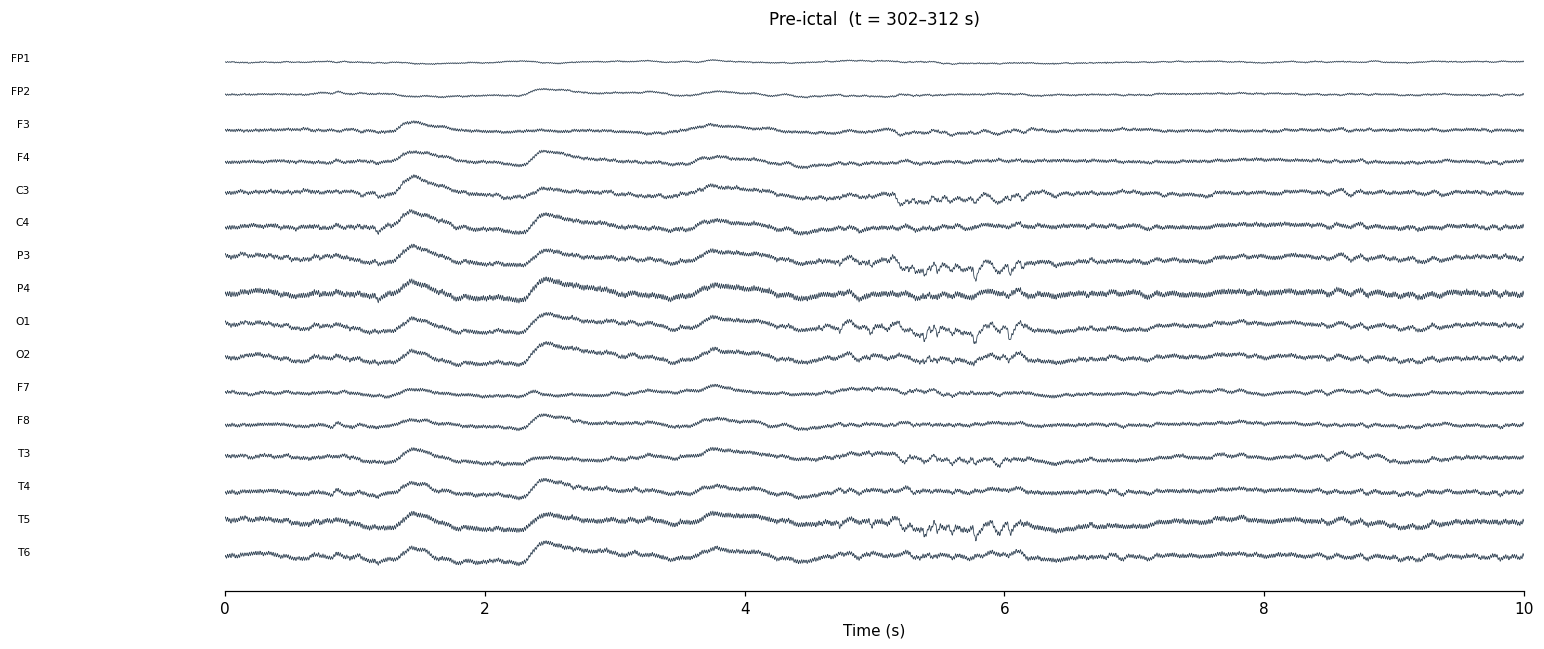

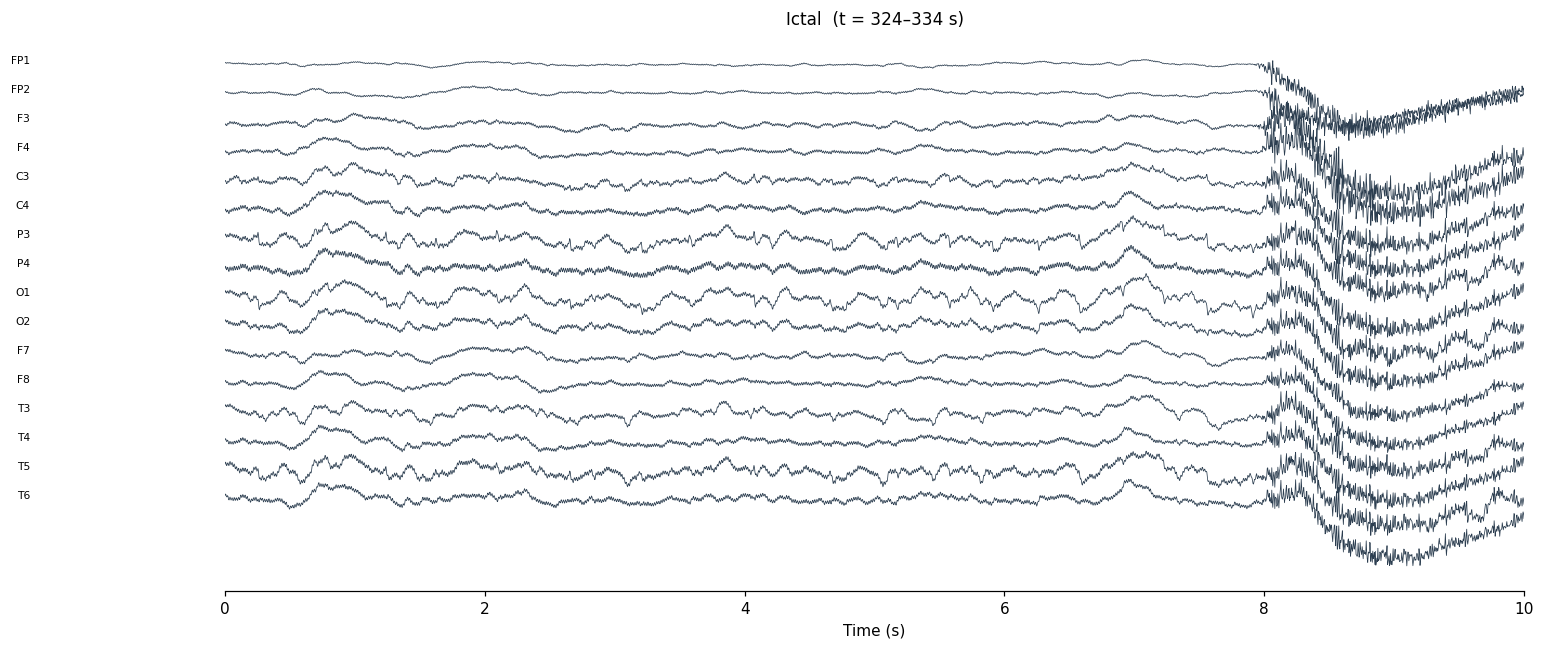

In [7]:
# Identify EEG channels (drop non-EEG)
NON_EEG = ['EKG', 'A1', 'A2', 'LOC', 'ROC', 'T1', 'T2', 'IBI', 'BURSTS', 'SUPPR', 'EMG',
            'C3P', 'C4P', 'SP1', 'SP2', '31-', '32-']
eeg_chs = [c for c in raw.ch_names if not any(x in c for x in NON_EEG)]
print(f'{len(eeg_chs)} EEG channels: {eeg_chs}')

def plot_eeg_stack(raw, t_start, dur_s=10, title='', n_show=16, scale=150):
    chs  = eeg_chs[:n_show]
    idxs = [raw.ch_names.index(c) for c in chs]
    i0, i1 = int(t_start * sfreq), int((t_start + dur_s) * sfreq)
    data = raw.get_data(picks=idxs)[:, i0:i1] * 1e6
    t    = np.linspace(0, dur_s, data.shape[1])
    fig, ax = plt.subplots(figsize=(14, 6))
    for k, (sig, name) in enumerate(zip(data, chs)):
        offset = (len(chs) - 1 - k) * scale
        ax.plot(t, sig + offset, lw=0.5, color='#2c3e50')
        ax.text(-0.15, offset, name.replace('EEG ', '').replace('-REF', ''),
                ha='right', va='center', fontsize=7, transform=ax.get_yaxis_transform())
    ax.set_xlabel('Time (s)'); ax.set_yticks([])
    ax.set_xlim(0, dur_s); ax.spines[['left','top','right']].set_visible(False)
    ax.set_title(title, fontsize=11); plt.tight_layout(); plt.show()

# First seizure at ~132 s
sz1_start = seiz_intervals.iloc[0]['start']
plot_eeg_stack(raw, sz1_start - 20, dur_s=10, title=f'Pre-ictal  (t = {sz1_start-20:.0f}–{sz1_start-10:.0f} s)')
plot_eeg_stack(raw, sz1_start + 2,  dur_s=10, title=f'Ictal  (t = {sz1_start+2:.0f}–{sz1_start+12:.0f} s)')

---
### Questions - Understanding the Data

**Q1.** How many seconds of seizure are in this recording, and how many seconds of background? Compute the ratio. What problem does this create for a classifier?

**Q2.** Looking at the raw EEG plots: what visually distinguishes the ictal from the pre-ictal trace? Which channels are most affected? What does that tell you about where the seizure is?

**Q3.** This recording has a sampling rate of 256 Hz. The Yobe State University Teaching Hospital EEG (`SUBJECT1.edf`) was recorded at 500 Hz. If you trained a model on TUSZ and applied it to the Yobe file, what must you do first, and why?

**Q4.** The annotations use bipolar channel names (`FP1-F7`) but the EDF stores referential channels (`EEG FP1-REF`). If you wanted to check which channels are annotated as seizing, what would you have to do to match them?

---
## Section 2 - Windowing & Seizure Labels

We divide the recording into fixed-length windows and assign binary labels:
- **1 (seizure)** - if ≥50% of the window overlaps with an annotated seizure interval  
- **0 (background)** - otherwise

We extract features in two parallel pipelines, starting from the **raw (bandpass-filtered) signal**:

In [8]:
# Bandpass filter (same as EEG_01)
raw_filt = raw.copy().filter(l_freq=0.5, h_freq=70.0, verbose=False)
raw_filt.notch_filter(freqs=60.0, verbose=False)   # 60 Hz US line noise
print('Bandpass 0.5-70 Hz + notch 60 Hz applied.')

# Extract only EEG channels as a numpy array
eeg_idx  = [raw_filt.ch_names.index(c) for c in eeg_chs]
data_raw = raw_filt.get_data(picks=eeg_idx) * 1e6   # (n_eeg_ch, n_samples)
n_eeg_ch, n_samp = data_raw.shape

WIN_SAMP = int(WIN_S * sfreq)
HOP_SAMP = int(HOP_S * sfreq)
starts   = np.arange(0, n_samp - WIN_SAMP + 1, HOP_SAMP)
n_win    = len(starts)
print(f'{n_eeg_ch} EEG channels, {n_win} windows ({WIN_S}s, {HOP_S}s hop)')

Bandpass 0.5-70 Hz + notch 60 Hz applied.
19 EEG channels, 899 windows (4.0s, 2.0s hop)


---
> **Note - Why filter before windowing, and why filter order matters**
>
> We apply the bandpass filter to the **full recording** before cutting windows.
> This is not arbitrary: filtering each window independently would introduce strong
> edge artifacts at every window boundary.
>
> However, filtering also introduces **ringing** - oscillatory artifacts that appear
> before and after sharp transients (like epileptic spikes). A higher-order filter
> has a steeper frequency rolloff but longer ringing. For band-power features, ringing
> near a seizure onset can inflate power in adjacent windows, creating apparent activity
> where there is none.
>
> MNE's `filter()` uses zero-phase (`filtfilt`) by default, so ringing is symmetric
> and does not cause pre-onset distortion - but it still spreads energy in time.
> Use moderate filter orders and be aware that features extracted from windows
> close to seizure boundaries are the most vulnerable.
>
> **Alternative:** end-to-end models (EEGNet, ShallowConvNet) receive minimally
> filtered or raw EEG and let the first convolutional layer learn its own frequency
> decomposition from data - avoiding artifacts introduced by hand-designed filters.


Total windows  : 899
Seizure (y=1)  : 39  (4.3%)
Background (y=0): 860  (95.7%)
Imbalance ratio : 22:1


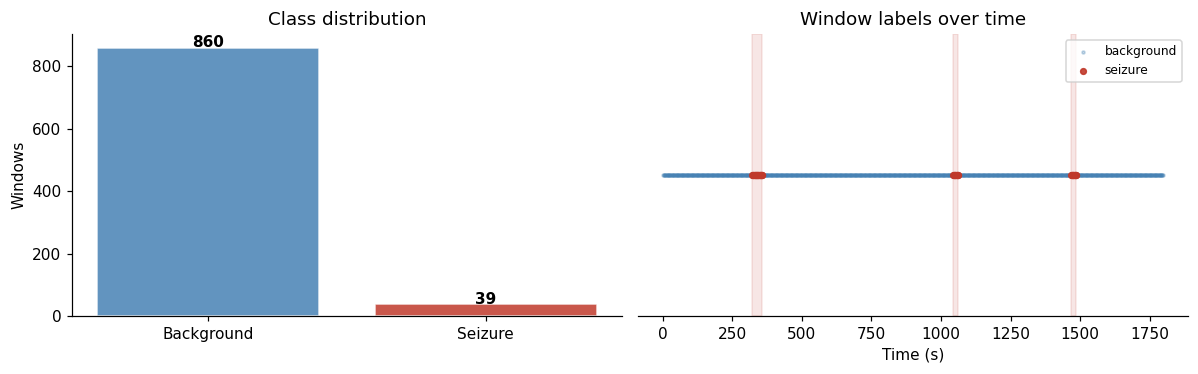

In [9]:
def label_windows(starts, win_samp, sfreq, seiz_intervals, thresh=0.5):
    """Binary label per window: 1 if seizure overlap >= thresh."""
    y = np.zeros(len(starts), dtype=int)
    win_s = win_samp / sfreq
    for wi, i0 in enumerate(starts):
        t0, t1 = i0 / sfreq, (i0 + win_samp) / sfreq
        total_overlap = 0.0
        for _, r in seiz_intervals.iterrows():
            total_overlap += max(0, min(t1, r['stop']) - max(t0, r['start']))
        y[wi] = 1 if total_overlap / win_s >= thresh else 0
    return y

y = label_windows(starts, WIN_SAMP, sfreq, seiz_intervals, THRESH)

n_seiz = y.sum()
n_bckg = (y == 0).sum()
ratio  = n_bckg / max(n_seiz, 1)

print(f'Total windows  : {n_win}')
print(f'Seizure (y=1)  : {n_seiz}  ({n_seiz/n_win*100:.1f}%)')
print(f'Background (y=0): {n_bckg}  ({n_bckg/n_win*100:.1f}%)')
print(f'Imbalance ratio : {ratio:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(['Background', 'Seizure'], [n_bckg, n_seiz],
            color=['steelblue', '#c0392b'], alpha=0.85, edgecolor='white')
for i, c in enumerate([n_bckg, n_seiz]):
    axes[0].text(i, c + 1, str(c), ha='center', fontweight='bold')
axes[0].set_ylabel('Windows'); axes[0].set_title('Class distribution')
axes[0].spines[['top','right']].set_visible(False)

t_ctr = (starts + WIN_SAMP // 2) / sfreq
axes[1].scatter(t_ctr[y==0], np.zeros(n_bckg), c='steelblue', s=4, alpha=0.3, label='background')
axes[1].scatter(t_ctr[y==1], np.zeros(n_seiz), c='#c0392b',   s=14, alpha=0.9, label='seizure')
for _, r in seiz_intervals.iterrows():
    axes[1].axvspan(r['start'], r['stop'], color='#c0392b', alpha=0.12)
axes[1].set_xlabel('Time (s)'); axes[1].set_yticks([])
axes[1].set_title('Window labels over time'); axes[1].legend(fontsize=8)
axes[1].spines[['top','right','left']].set_visible(False)
plt.tight_layout(); plt.show()

---
### Questions - Windowing

**Q5.** A common mistake is to split windows randomly into train and test sets. Why is this a problem for EEG seizure data? *(Hint: think about what windows from the same seizure have in common.)*

**Q6.** Look at the imbalance ratio printed above. A naive classifier that always predicts "background" achieves what accuracy? Why is accuracy a misleading metric here? What two metrics would you use instead?

**Q7.** We set the seizure label threshold at 50% overlap. What happens to the number of seizure windows if you lower it to 10%? Would that be a good idea? Why or why not?

**Q4b.** We filtered the full recording at 0.5-70 Hz before windowing. A high-order filter introduces *ringing* near sharp transients. Which windows in this dataset are most at risk of having inflated band-power features due to ringing? Would the MLP or the CNN be more affected, and why?

---
## Section 3 - Feature Extraction: Band-power

The MLP needs handcrafted features. We use the same 5-band power features computed in EEG_01: for each window, compute the Welch PSD and integrate over each band, for every EEG channel.

**Feature vector size:** 5 bands × N channels - one scalar per band per channel.

In [10]:
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

def band_power(freqs, psd, fmin, fmax):
    idx = (freqs >= fmin) & (freqs <= fmax)
    return float(_trapz(psd[idx], freqs[idx]))

def extract_bandpower(data, starts, win_samp, sfreq, bands):
    """Extract band-power features.  Returns (n_win, n_ch * n_bands) array."""
    n_ch, n_bands = data.shape[0], len(bands)
    nperseg = min(int(2 * sfreq), win_samp)
    X = np.zeros((len(starts), n_ch * n_bands))
    for wi, i0 in enumerate(starts):
        feat = []
        for ch_sig in data[:, i0: i0 + win_samp]:
            fr, psd = sp.welch(ch_sig, fs=sfreq, nperseg=nperseg)
            feat.extend(band_power(fr, psd, flo, fhi) for flo, fhi in bands.values())
        X[wi] = feat
    return X

print('Extracting band-power features from raw filtered signal...')
X_bp = extract_bandpower(data_raw, starts, WIN_SAMP, sfreq, BANDS)
print(f'Feature matrix: {X_bp.shape}  ({n_eeg_ch} channels × {len(BANDS)} bands)')

Extracting band-power features from raw filtered signal...
Feature matrix: (899, 95)  (19 channels × 5 bands)


---
## Section 3b - Multi-patient Dataset

So far we have processed a *single recording* from one patient. A model trained on one person's EEG will almost certainly fail on a new patient - EEG varies enormously across individuals due to anatomy, skull thickness, alertness state, and medication.

Pooling several patients gives the model a chance to learn patterns that generalize beyond one individual. It also introduces a new challenge: *channel alignment* - not all recordings have exactly the same set of EEG channels. We handle this by keeping only channels that appear in every recording.

**Training patients (TUSZ dev, 01_tcp_ar, 256 Hz):**

| Patient | Recording | Duration | Seizures | Type |
|---|---|---|---|---|
| `aaaaasgd` | `s001_t000` | ~30 min | 3 (36 s + 21 s + 19 s) | fnsz |
| `aaaaampk` | `s007_t001` | ~20 min | multiple (~55–90 s each) | gnsz + fnsz |
| `aaaaaoys` | `s002_t004` | ~25 min | 2 (~90 s + ~119 s) | gnsz |

We write a `process_recording()` function that applies the full pipeline to any TUSZ EDF + CSV pair. We then loop over all three patients, collect windows and labels, and concatenate them into a single multi-patient training set.

Loading training recordings...

  aaaaasgd_s001_t000.edf           899 windows  seizure=39 (4.3%)  channels=19
  aaaaampk_s007_t001.edf           589 windows  seizure=306 (52.0%)  channels=20
  aaaaaoys_s002_t004.edf           764 windows  seizure=106 (13.9%)  channels=19

Channels in common across all recordings: 19

Combined dataset:
  Band-power features : (2252, 95)
  Raw windows         : (2252, 19, 1024)
  Labels              : (2252,)
  Seizure windows     : 451  (20.0%)
  Background windows  : 1801  (80.0%)


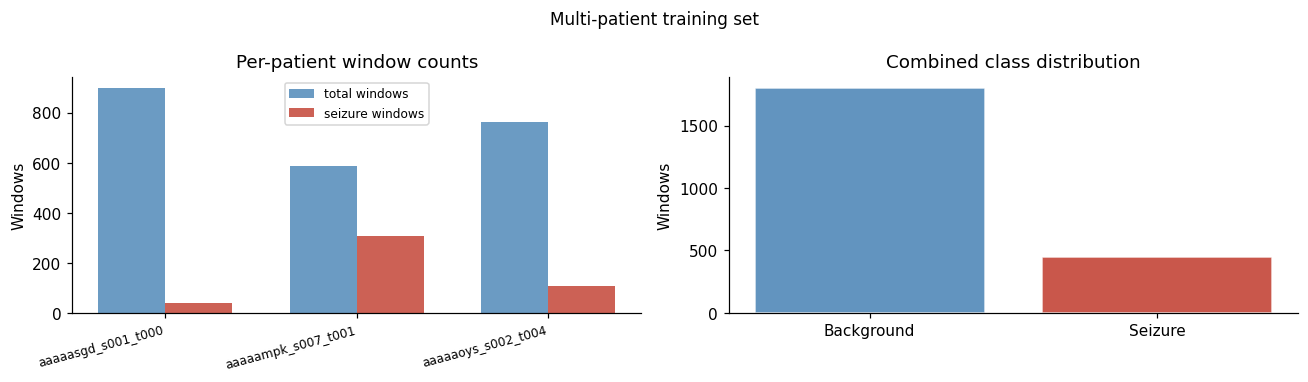

In [11]:
import glob

def process_recording(edf_path, csv_path, win_samp, hop_samp, sfreq, bands, thresh=0.5):
    """
    Load one TUSZ recording, bandpass-filter, window, label, and extract features.
    Returns (X_bp, X_raw, y, ch_names) where:
      X_bp     — (n_win, n_ch * n_bands)  band-power features
      X_raw    — (n_win, n_ch, win_samp)  raw windowed signal
      y        — (n_win,)                 binary seizure labels
      ch_names — ordered list of EEG channel names in this recording
    """
    raw_r = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    eeg_r = [c for c in raw_r.ch_names if not any(x in c for x in NON_EEG)]
    raw_r.pick(eeg_r)
    raw_r.filter(l_freq=0.5, h_freq=70.0, verbose=False)
    raw_r.notch_filter(freqs=60.0, verbose=False)
    data_r = raw_r.get_data() * 1e6

    seiz_r = read_tusz_csv(csv_path)
    seiz_intervals_r = merge_seizure_intervals(seiz_r)   # union across all channels

    n_samp_r = data_r.shape[1]
    starts_r  = np.arange(0, n_samp_r - win_samp + 1, hop_samp)
    y_r       = label_windows(starts_r, win_samp, sfreq, seiz_intervals_r, thresh)
    X_bp_r    = extract_bandpower(data_r, starts_r, win_samp, sfreq, bands)
    X_raw_r   = np.stack([data_r[:, i0: i0 + win_samp] for i0 in starts_r])

    n_sz = y_r.sum()
    print(f'  {os.path.basename(edf_path):30s}  '
          f'{len(starts_r):4d} windows  '
          f'seizure={n_sz} ({n_sz/len(y_r)*100:.1f}%)  '
          f'channels={len(eeg_r)}')

    return X_bp_r, X_raw_r, y_r, list(raw_r.ch_names)   # ordered list


# ── Recordings to combine ──────────────────────────────────────────────────────
TRAINING_BNAMES = [
    ('aaaaasgd', 's001_2015', 'aaaaasgd_s001_t000'),   # already explored above
    ('aaaaampk', 's007_2012', 'aaaaampk_s007_t001'),
    ('aaaaaoys', 's002_2013', 'aaaaaoys_s002_t004'),
]

def find_edf(tusz_root, split, patient, bname, montage='01_tcp_ar'):
    pattern = os.path.join(tusz_root, split, patient, '*', montage, bname + '.edf')
    hits = glob.glob(pattern)
    if not hits:
        raise FileNotFoundError(f'No EDF found for pattern: {pattern}')
    return hits[0], hits[0].replace('.edf', '.csv')


# ── Load and process each recording ───────────────────────────────────────────
print('Loading training recordings...\n')
all_X_bp, all_X_raw, all_y, all_ch_lists = [], [], [], []

for patient, session, bname in TRAINING_BNAMES:
    try:
        edf_p, csv_p = find_edf(TUSZ_ROOT, 'dev', patient, bname)
        X_bp_r, X_raw_r, y_r, ch_r = process_recording(
            edf_p, csv_p, WIN_SAMP, HOP_SAMP, sfreq, BANDS)
        all_X_bp.append(X_bp_r)
        all_X_raw.append(X_raw_r)
        all_y.append(y_r)
        all_ch_lists.append(ch_r)   # ordered list — position matters for reindexing
    except FileNotFoundError as e:
        print(f'  SKIPPED — {e}')

# ── Channel alignment: keep only channels present in ALL recordings ────────────
# Preserve channel order from first recording rather than sorting alphabetically
# (so cnn_multi and cnn_online use the same channel-index mapping)
common_chs  = [c for c in all_ch_lists[0]
               if all(c in set(ch) for ch in all_ch_lists[1:])]
n_ch_common = len(common_chs)
n_bands_    = len(BANDS)
print(f'\nChannels in common across all recordings: {n_ch_common}')

# Reindex both X_bp and X_raw to the common channel set.
# X_bp layout: ch0_band0 … ch0_band4, ch1_band0 … (channels outer, bands inner)
# So channel at position i contributes columns [i*n_bands : (i+1)*n_bands].
aligned_X_bp, aligned_X_raw = [], []
for X_bp_r, X_raw_r, ch_list in zip(all_X_bp, all_X_raw, all_ch_lists):
    idx     = [ch_list.index(c) for c in common_chs]          # position of each common ch
    bp_cols = [i * n_bands_ + b for i in idx for b in range(n_bands_)]
    aligned_X_bp.append(X_bp_r[:, bp_cols])
    aligned_X_raw.append(X_raw_r[:, idx, :])

# ── Concatenate ───────────────────────────────────────────────────────────────
X_bp_multi  = np.concatenate(aligned_X_bp,  axis=0)
X_raw_multi = np.concatenate(aligned_X_raw, axis=0)
y_multi     = np.concatenate(all_y,          axis=0)

print(f'\nCombined dataset:')
print(f'  Band-power features : {X_bp_multi.shape}')
print(f'  Raw windows         : {X_raw_multi.shape}')
print(f'  Labels              : {y_multi.shape}')
n_sz_tot = y_multi.sum()
print(f'  Seizure windows     : {n_sz_tot}  ({n_sz_tot/len(y_multi)*100:.1f}%)')
print(f'  Background windows  : {len(y_multi)-n_sz_tot}  ({(len(y_multi)-n_sz_tot)/len(y_multi)*100:.1f}%)')

# ── Per-patient breakdown bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
names  = [b for _, _, b in TRAINING_BNAMES[:len(all_y)]]
n_wins = [len(y) for y in all_y]
n_szs  = [y.sum() for y in all_y]
x      = np.arange(len(names))
w      = 0.35
axes[0].bar(x - w/2, n_wins, w, label='total windows', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, n_szs,  w, label='seizure windows', color='#c0392b', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Windows'); axes[0].set_title('Per-patient window counts')
axes[0].legend(fontsize=8); axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(['Background', 'Seizure'], [len(y_multi)-n_sz_tot, n_sz_tot],
            color=['steelblue','#c0392b'], alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Windows'); axes[1].set_title('Combined class distribution')
axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Multi-patient training set', fontsize=11)
plt.tight_layout(); plt.show()

---
### Questions - Multi-patient Dataset

**Q3b-1.** After combining three patients, how does the total seizure window count compare to the single-patient dataset? Does the class imbalance improve or worsen?

**Q3b-2.** The three recordings include different seizure types: `fnsz` (focal non-motor onset) and `gnsz` (generalized non-motor onset). These have different EEG signatures - focal seizures start in one region, generalized seizures involve both hemispheres simultaneously. Does pooling different seizure types help or hurt a detector that will be deployed clinically? Justify your answer.

**Q3b-3.** We aligned channels by taking the **intersection** (channels present in all recordings). An alternative is the **union** - keep all channels and fill missing ones with zeros. What are the trade-offs? When would you prefer union over intersection?

**Q3b-4.** The `process_recording()` function applies the same bandpass filter and windowing to every recording. What assumption does this make about the recordings? Is it valid here? Would it hold if you added a recording at 500 Hz or with a different electrode placement?

**Q3b-5.** You now have `X_bp_multi`, `X_raw_multi`, and `y_multi`. Retrain the MLP and CNN using these multi-patient arrays instead of the single-patient ones. Does performance on the held-out patient (Section 7) improve? What does the result tell you about the value of multi-patient training?

---
## Section 4 - Model A: MLP on Band-power Features

A multilayer perceptron (MLP) is a stack of fully-connected layers. Each layer learns a linear combination of its inputs, followed by a non-linearity (ReLU). Given the class imbalance, we use **class weights** to penalize missed seizures more than false alarms.

In [12]:
class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.net(x)


def make_split(X, y, test_frac=0.2, mode='random', seed=42):
    """Return (X_train, y_train, X_test, y_test).
    mode='random'  → shuffle split (standard but leaky for EEG)
    mode='time'    → first (1-test_frac) windows train, rest test
    """
    n = len(y)
    if mode == 'time':
        cut = int(n * (1 - test_frac))
        return X[:cut], y[:cut], X[cut:], y[cut:]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    cut = int(n * (1 - test_frac))
    tr, te = idx[:cut], idx[cut:]
    return X[tr], y[tr], X[te], y[te]


def make_loader(X_np, y_np, batch=64, oversample=True):
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_np).astype(np.float32)
    Xt = torch.tensor(X_sc)
    yt = torch.tensor(y_np, dtype=torch.long)
    ds = TensorDataset(Xt, yt)
    if oversample and y_np.sum() > 0:
        counts = np.bincount(y_np)
        w = 1.0 / counts[y_np]
        sampler = WeightedRandomSampler(torch.tensor(w), len(y_np))
        return DataLoader(ds, batch_size=batch, sampler=sampler), scaler
    return DataLoader(ds, batch_size=batch, shuffle=True), scaler


def train_model(model, loader_tr, loader_te=None, epochs=40, lr=1e-3):
    """Train with Adam + cross-entropy. Returns (train_losses, test_losses)."""
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    tr_losses, te_losses = [], []
    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for xb, yb in loader_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(yb)
        tr_losses.append(ep_loss / len(loader_tr.dataset))
        if loader_te is not None:
            model.eval()
            with torch.no_grad():
                te_loss = sum(loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                              for xb, yb in loader_te)
            te_losses.append(te_loss / len(loader_te.dataset))
    return tr_losses, te_losses


@torch.no_grad()
def predict(model, X_np, scaler):
    model.eval().to(DEVICE)
    X_sc = torch.tensor(scaler.transform(X_np).astype(np.float32)).to(DEVICE)
    return model(X_sc).argmax(dim=1).cpu().numpy()


def eval_report(y_true, y_pred, title=''):
    # labels=[0,1] forces a 2×2 matrix even when one class is absent in test
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    acc  = (tp + tn) / len(y_true)
    print(f'\n── {title} ──')
    print(f'  Accuracy    : {acc:.3f}')
    print(f'  Sensitivity : {sens:.3f}  (true positive rate — seizures correctly detected)')
    print(f'  Specificity : {spec:.3f}  (true negative rate — background correctly rejected)')
    print(f'  Confusion matrix:')
    print(f'    Pred 0  Pred 1')
    print(f'  [{tn:6d}  {fp:6d}]  True 0 (background)')
    print(f'  [{fn:6d}  {tp:6d}]  True 1 (seizure)')
    return dict(acc=acc, sens=sens, spec=spec)


print('Utilities defined.')

Utilities defined.


MLP: 20,674 parameters
MLP(
  (net): Sequential(
    (0): Linear(in_features=95, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


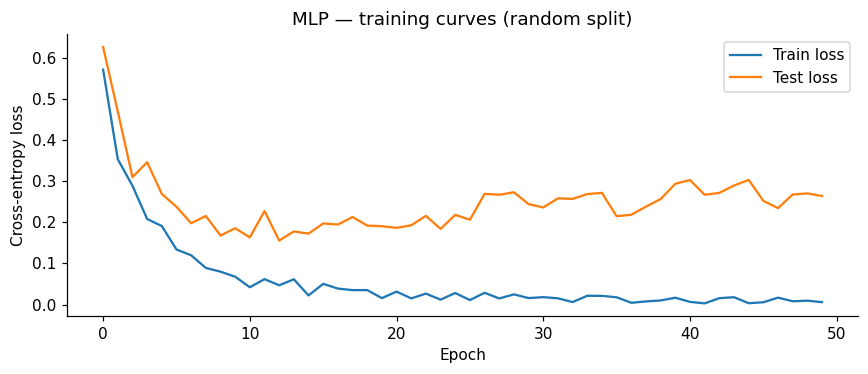


── MLP / band-power / raw signal / random split ──
  Accuracy    : 0.961
  Sensitivity : 0.500  (true positive rate — seizures correctly detected)
  Specificity : 0.988  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   168       2]  True 0 (background)
  [     5       5]  True 1 (seizure)


In [13]:
# Random split (standard — but see Section 6 for why this is optimistic)
X_tr, y_tr, X_te, y_te = make_split(X_bp, y, mode='random')

loader_tr, scaler_mlp = make_loader(X_tr, y_tr, oversample=True)
loader_te, _          = make_loader(X_te, y_te, oversample=False)

mlp = MLP(n_features=X_bp.shape[1])
print(f'MLP: {sum(p.numel() for p in mlp.parameters()):,} parameters')
print(mlp)

tr_loss, te_loss = train_model(mlp, loader_tr, loader_te, epochs=50)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(tr_loss, label='Train loss')
ax.plot(te_loss, label='Test loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('MLP — training curves (random split)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

y_pred_mlp = predict(mlp, X_te, scaler_mlp)
metrics_mlp_raw = eval_report(y_te, y_pred_mlp, 'MLP / band-power / raw signal / random split')

---
### Questions - MLP

**Q8.** Look at the sensitivity and specificity. Which one matters more clinically - detecting every seizure (high sensitivity) or avoiding false alarms (high specificity)? Does your answer change if the model is used in an ICU vs. a rural clinic without a neurologist?

**Q9.** We use `WeightedRandomSampler` to oversample the minority class. Remove it (set `oversample=False`) and retrain. What happens to sensitivity? Why?

**Q10.** The MLP has no information about the **order** of features within a window. Does that matter for band-power features? Would it matter if we fed raw samples instead?

---
## Section 5 - Model B: 1D-CNN on Raw Signal

The CNN receives the **raw bandpass-filtered EEG** - no feature engineering. It learns which temporal patterns are predictive, directly from the signal.

**Architecture:**
```
Input: (batch, n_channels, n_samples)  →  e.g. (64, 19, 1024)

Block 1: Conv1d(n_ch → 32, kernel=25)  BatchNorm  ReLU  MaxPool(4)
Block 2: Conv1d(32 → 64, kernel=10)   BatchNorm  ReLU  MaxPool(4)
Block 3: Conv1d(64 → 128, kernel=5)   BatchNorm  ReLU  AdaptiveAvgPool(8)

Flatten  →  FC(1024→64)  ReLU  Dropout(0.5)  →  FC(64→2)
```

Each Conv1d kernel slides across **time**, seeing all `n_channels` at once at each position - so spatial (channel) mixing happens implicitly.

In [14]:
class EEGNet1D(nn.Module):
    def __init__(self, n_channels, n_samples):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1 — coarse temporal features (~100 ms)
            nn.Conv1d(n_channels, 32, kernel_size=25, padding=12),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            # Block 2 — mid-range features (~160 ms)
            nn.Conv1d(32, 64, kernel_size=10, padding=5),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            # Block 3 — fine features
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(8),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.classifier(self.encoder(x))


# Sanity check — run one fake batch through
dummy = torch.zeros(4, n_eeg_ch, WIN_SAMP)
cnn_dummy = EEGNet1D(n_eeg_ch, WIN_SAMP)
out = cnn_dummy(dummy)
print(f'Input shape : {tuple(dummy.shape)}')
print(f'Output shape: {tuple(out.shape)}  (batch × 2 classes)')
print(f'CNN parameters: {sum(p.numel() for p in cnn_dummy.parameters()):,}')
print()
print(cnn_dummy)

Input shape : (4, 19, 1024)
Output shape: (4, 2)  (batch × 2 classes)
CNN parameters: 143,042

EEGNet1D(
  (encoder): Sequential(
    (0): Conv1d(19, 32, kernel_size=(25,), stride=(1,), padding=(12,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(10,), stride=(1,), padding=(5,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=8)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=64, bias=T

In [15]:
# Build raw-signal windows: shape (n_win, n_eeg_ch, WIN_SAMP)
X_raw = np.stack([data_raw[:, i0: i0 + WIN_SAMP] for i0 in starts])  # (n_win, ch, samples)
print(f'Raw window tensor: {X_raw.shape}  ({n_win} windows × {n_eeg_ch} ch × {WIN_SAMP} samples)')


def make_raw_loader(X_np, y_np, batch=32, oversample=True):
    """Same as make_loader but for 3-D raw windows; normalize per window."""
    # z-score each window independently across time
    mu  = X_np.mean(axis=2, keepdims=True)
    std = X_np.std(axis=2, keepdims=True) + 1e-8
    X_sc = ((X_np - mu) / std).astype(np.float32)
    Xt = torch.tensor(X_sc)
    yt = torch.tensor(y_np, dtype=torch.long)
    ds = TensorDataset(Xt, yt)
    if oversample and y_np.sum() > 0:
        counts = np.bincount(y_np)
        w = 1.0 / counts[y_np]
        sampler = WeightedRandomSampler(torch.tensor(w), len(y_np))
        return DataLoader(ds, batch_size=batch, sampler=sampler)
    return DataLoader(ds, batch_size=batch, shuffle=True)


@torch.no_grad()
def predict_raw(model, X_np):
    model.eval().to(DEVICE)
    mu  = X_np.mean(axis=2, keepdims=True)
    std = X_np.std(axis=2, keepdims=True) + 1e-8
    X_sc = torch.tensor(((X_np - mu) / std).astype(np.float32)).to(DEVICE)
    return model(X_sc).argmax(dim=1).cpu().numpy()


# Same random split, but applied to raw windows
X_tr_r, y_tr_r, X_te_r, y_te_r = make_split(X_raw, y, mode='random')

Raw window tensor: (899, 19, 1024)  (899 windows × 19 ch × 1024 samples)


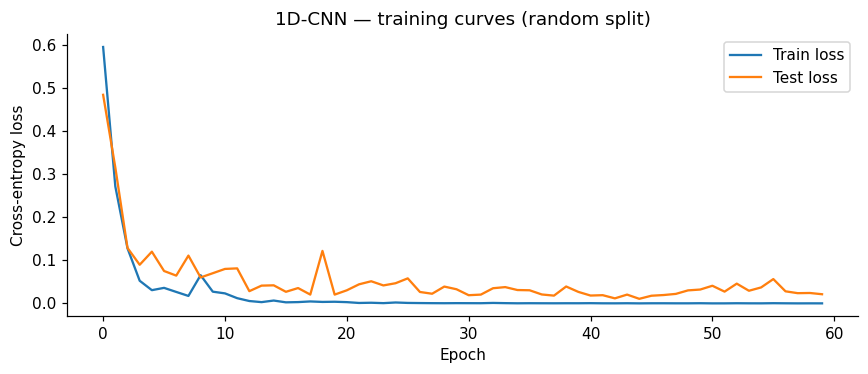


── 1D-CNN / raw signal / random split ──
  Accuracy    : 0.989
  Sensitivity : 0.800  (true positive rate — seizures correctly detected)
  Specificity : 1.000  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   170       0]  True 0 (background)
  [     2       8]  True 1 (seizure)


In [16]:
loader_tr_r = make_raw_loader(X_tr_r, y_tr_r, oversample=True)
loader_te_r = make_raw_loader(X_te_r, y_te_r, oversample=False)

cnn = EEGNet1D(n_eeg_ch, WIN_SAMP)
loss_fn_cnn = nn.CrossEntropyLoss()

# Training loop
cnn.to(DEVICE)
opt_cnn = torch.optim.Adam(cnn.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(opt_cnn, step_size=20, gamma=0.5)

tr_losses_cnn, te_losses_cnn = [], []
for ep in range(60):
    cnn.train()
    ep_loss = 0
    for xb, yb in loader_tr_r:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_cnn.zero_grad()
        loss = loss_fn_cnn(cnn(xb), yb)
        loss.backward(); opt_cnn.step()
        ep_loss += loss.item() * len(yb)
    tr_losses_cnn.append(ep_loss / len(loader_tr_r.dataset))
    cnn.eval()
    with torch.no_grad():
        te_loss = sum(loss_fn_cnn(cnn(xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                      for xb, yb in loader_te_r)
    te_losses_cnn.append(te_loss / len(loader_te_r.dataset))
    scheduler.step()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(tr_losses_cnn, label='Train loss')
ax.plot(te_losses_cnn, label='Test loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('1D-CNN — training curves (random split)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

y_pred_cnn = predict_raw(cnn, X_te_r)
metrics_cnn_raw = eval_report(y_te_r, y_pred_cnn, '1D-CNN / raw signal / random split')

---
### Questions - 1D-CNN

**Q11.** The first Conv1d layer has `kernel_size=25`. At 256 Hz, how many milliseconds does this kernel span? What EEG phenomena happen at that timescale?

**Q12.** The CNN has ~10× more parameters than the MLP. Does more parameters always mean better performance? What risk does this introduce, and how does dropout help?

**Q13.** We normalize each raw window by its own mean and standard deviation (z-score). Why? What would happen if we normalized globally across all windows instead?

**Q14.** Compare MLP vs CNN sensitivity and specificity. Which model is better at detecting seizures? Which produces more false alarms? Formulate a hypothesis for why.

**Q14b.** The CNN receives bandpass-filtered EEG as input. End-to-end architectures like EEGNet and ShallowConvNet instead operate on minimally filtered raw EEG, letting the first layer learn its own frequency decomposition. Name one advantage and one disadvantage of the end-to-end approach compared to using a hand-designed bandpass filter before the network.

---
## Section 5 - Does Preprocessing Help?

The lecture stated: *"Preprocessing is not optional - filter and remove artifacts before training, so the model learns seizures, not equipment signatures."*

Now let's test that claim empirically. We apply the same ICA artifact removal pipeline from EEG_01 and compare performance **with vs. without preprocessing** for both models.

The hypothesis:
- For the **MLP** (band-power features), artifacts should hurt performance - muscle noise inflates gamma power and eye blinks inflate frontal delta/theta.
- For the **CNN** (raw signal), it might learn to ignore artifacts - or it might learn to use them as a confound if artifacts correlate with seizures.

In [17]:
from mne.preprocessing import ICA as _ICA

raw_ica_in = raw_filt.copy().pick(eeg_chs)
raw_ica_in.set_channel_types({ch: 'eeg' for ch in raw_ica_in.ch_names})
raw_ica_ref = raw_ica_in.copy().set_eeg_reference('average', projection=True, verbose=False)
raw_ica_ref.apply_proj()

# Fit ICA on the pre-seizure segment only.  When the full recording contains
# seizures, ictal bursts inflate the covariance and push the eye component to a
# lower-variance IC where find_bads_eog may miss it at the default z=3 threshold.
pre_seiz_s = float(seiz_intervals.iloc[0]['start']) - 20.0   # 20 s before Seizure 1
ica_fit_data = raw_ica_ref.copy().crop(tmax=max(pre_seiz_s, 60.0))
print(f'Fitting ICA on pre-seizure segment (0 – {ica_fit_data.times[-1]:.0f} s) ...')

ica = _ICA(n_components=15, method='fastica', random_state=SEED, max_iter=1000)
ica.fit(ica_fit_data, verbose=False)

fp_chs = [c for c in raw_ica_ref.ch_names if 'FP1' in c or 'FP2' in c]
eog_idx, scores = ica.find_bads_eog(raw_ica_ref, ch_name=fp_chs, verbose=False)
if not eog_idx:                         # z=3 not met — relax threshold to z=2
    eog_idx, scores = ica.find_bads_eog(raw_ica_ref, ch_name=fp_chs,
                                         threshold=2.0, verbose=False)
    if eog_idx:
        print('  (threshold relaxed to z=2.0 to detect eye component)')

scores_arr = np.abs(scores).max(axis=0) if np.ndim(scores) > 1 else np.abs(scores)
print(f'Top-5 eye-component scores: {sorted(scores_arr, reverse=True)[:5]}')
ica.exclude = eog_idx
raw_clean = ica.apply(raw_ica_ref.copy(), verbose=False)

data_clean = raw_clean.get_data() * 1e6
print(f'ICA done. Removed {len(eog_idx)} eye component(s): {eog_idx}')
print(f'Clean data shape: {data_clean.shape}')

Fitting ICA on pre-seizure segment (0 – 302 s) ...
  (threshold relaxed to z=2.0 to detect eye component)
Top-5 eye-component scores: [np.float64(0.6736388789401364), np.float64(0.5357079925063712), np.float64(0.5090695423161008), np.float64(0.33625698642389296), np.float64(0.2758429921430865)]
ICA done. Removed 2 eye component(s): [np.int64(5), np.int64(8)]
Clean data shape: (19, 460800)


In [18]:
# Extract features from ICA-cleaned signal
print('Extracting band-power features from ICA-cleaned signal...')
X_bp_clean = extract_bandpower(data_clean, starts, WIN_SAMP, sfreq, BANDS)
X_raw_clean = np.stack([data_clean[:, i0: i0 + WIN_SAMP] for i0 in starts])

# Train MLP on cleaned features (same random split indices)
rng = np.random.default_rng(SEED)
idx_all = rng.permutation(len(y))
cut = int(len(y) * 0.8)
tr_idx, te_idx = idx_all[:cut], idx_all[cut:]

loader_tr_cl, scaler_cl = make_loader(X_bp_clean[tr_idx], y[tr_idx], oversample=True)
loader_te_cl, _         = make_loader(X_bp_clean[te_idx], y[te_idx], oversample=False)

mlp_clean = MLP(n_features=X_bp_clean.shape[1])
train_model(mlp_clean, loader_tr_cl, epochs=50)
y_pred_mlp_clean = predict(mlp_clean, X_bp_clean[te_idx], scaler_cl)
metrics_mlp_clean = eval_report(y[te_idx], y_pred_mlp_clean, 'MLP / band-power / ICA-cleaned / random split')

# Train CNN on cleaned raw windows
loader_tr_cr = make_raw_loader(X_raw_clean[tr_idx], y[tr_idx], oversample=True)
loader_te_cr = make_raw_loader(X_raw_clean[te_idx], y[te_idx], oversample=False)

cnn_clean = EEGNet1D(n_eeg_ch, WIN_SAMP)
cnn_clean.to(DEVICE)
opt_cc = torch.optim.Adam(cnn_clean.parameters(), lr=5e-4, weight_decay=1e-4)
for ep in range(60):
    cnn_clean.train()
    for xb, yb in loader_tr_cr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_cc.zero_grad()
        loss_fn_cnn(cnn_clean(xb), yb).backward(); opt_cc.step()

y_pred_cnn_clean = predict_raw(cnn_clean, X_raw_clean[te_idx])
metrics_cnn_clean = eval_report(y[te_idx], y_pred_cnn_clean, '1D-CNN / raw signal / ICA-cleaned / random split')

Extracting band-power features from ICA-cleaned signal...

── MLP / band-power / ICA-cleaned / random split ──
  Accuracy    : 0.983
  Sensitivity : 0.700  (true positive rate — seizures correctly detected)
  Specificity : 1.000  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   170       0]  True 0 (background)
  [     3       7]  True 1 (seizure)

── 1D-CNN / raw signal / ICA-cleaned / random split ──
  Accuracy    : 0.983
  Sensitivity : 0.800  (true positive rate — seizures correctly detected)
  Specificity : 0.994  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   169       1]  True 0 (background)
  [     2       8]  True 1 (seizure)



Model                       Accuracy   Sensitivity   Specificity
-----------------------------------------------------------------
MLP / raw                      0.961         0.500         0.988
MLP / ICA                      0.983         0.700         1.000
CNN / raw                      0.989         0.800         1.000
CNN / ICA                      0.983         0.800         0.994


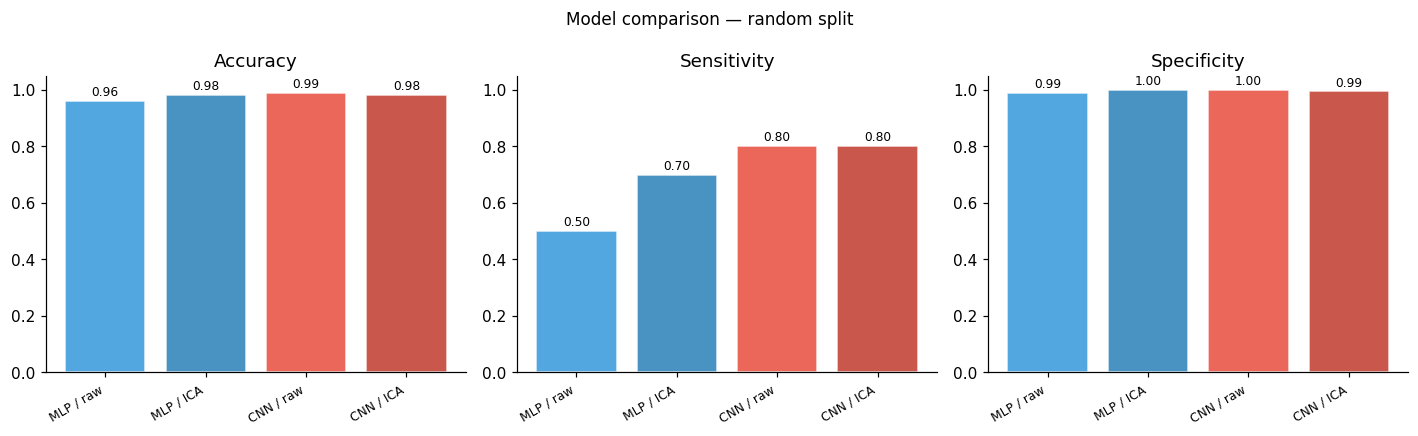

In [19]:
# Summary comparison table
results = {
    'MLP / raw':       metrics_mlp_raw,
    'MLP / ICA':       metrics_mlp_clean,
    'CNN / raw':       metrics_cnn_raw,
    'CNN / ICA':       metrics_cnn_clean,
}

print(f'\n{"Model":25s}  {"Accuracy":>9s}  {"Sensitivity":>12s}  {"Specificity":>12s}')
print('-' * 65)
for name, m in results.items():
    print(f'{name:25s}  {m["acc"]:9.3f}  {m["sens"]:12.3f}  {m["spec"]:12.3f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
labels = list(results.keys())
colors = ['#3498db','#2980b9','#e74c3c','#c0392b']
for ax, metric in zip(axes, ['acc','sens','spec']):
    vals = [results[k][metric] for k in labels]
    bars = ax.bar(range(len(labels)), vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title({'acc':'Accuracy','sens':'Sensitivity','spec':'Specificity'}[metric])
    ax.spines[['top','right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                ha='center', fontsize=8)
plt.suptitle('Model comparison — random split', fontsize=11)
plt.tight_layout(); plt.show()

---
### Questions - Does Preprocessing Help?

**Q15.** Compare MLP/raw vs MLP/ICA. Did removing eye artifacts improve sensitivity, specificity, or both? Explain *why* in terms of which features are affected by eye blinks.

**Q16.** Compare CNN/raw vs CNN/ICA. Did ICA preprocessing help the CNN as much as it helped the MLP? What does this tell you about the CNN's ability to handle artifacts?

**Q17.** ICA adds computation time and requires clean, monopolar recordings with enough channels. Given your results, when is preprocessing *worth the effort* and when could you skip it?

**Q18.** The lecture said *"preprocessing is not optional."* Do your results support or challenge that claim? Under what conditions might it be wrong?

---
## Section 6 - The Online Challenge

All comparisons above used a **random split** - train and test windows are shuffled and drawn from the same time period. This is unrealistic: in deployment, the model sees future data it has never seen before.

**Time-based split:** train on the first 80% of the recording (in time), test on the last 20%. This simulates a model trained overnight and deployed the next morning.

Two additional constraints that matter in a real system:
1. The model must decide **window by window**, with no look-ahead
2. **Detection latency** - how many seconds pass between seizure onset and the first correct positive prediction?

In [20]:
# Time axis for test window — depends only on Section 2 variables (starts, y, WIN_SAMP, HOP_S, sfreq)
# Defined first so it is available for online-viz even if training below fails
t_cut    = int(len(y) * 0.8) * HOP_S
t_ctr_te = (starts[int(len(y) * 0.8):] + WIN_SAMP // 2) / sfreq

# Time-split for best model (CNN / ICA-cleaned)
X_tr_t, y_tr_t, X_te_t, y_te_t = make_split(X_raw_clean, y, mode='time', test_frac=0.2)
print(f'Time split:  train={len(y_tr_t)} windows  test={len(y_te_t)} windows')
print(f'Train seizure windows: {y_tr_t.sum()}  Test seizure windows: {y_te_t.sum()}')

loader_tr_t = make_raw_loader(X_tr_t, y_tr_t, oversample=True)
cnn_online = EEGNet1D(n_eeg_ch, WIN_SAMP)
cnn_online.to(DEVICE)
opt_on = torch.optim.Adam(cnn_online.parameters(), lr=5e-4, weight_decay=1e-4)
for ep in range(60):
    cnn_online.train()
    for xb, yb in loader_tr_t:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_on.zero_grad()
        loss_fn_cnn(cnn_online(xb), yb).backward(); opt_on.step()

y_pred_online = predict_raw(cnn_online, X_te_t)
metrics_online = eval_report(y_te_t, y_pred_online, 'CNN / ICA / time split (online)')

print('\n── Seizure detection latency ──')
for _, r in seiz_intervals.iterrows():
    if r['stop'] < t_cut: continue
    onset = r['start']
    first_det = None
    for t, pred in zip(t_ctr_te, y_pred_online):
        if t >= onset and pred == 1:
            first_det = t
            break
    if first_det is not None:
        print(f"  Seizure at {onset:.0f}s → first detection at {first_det:.0f}s "
              f"→ latency = {first_det - onset:.1f}s")
    else:
        print(f"  Seizure at {onset:.0f}s → MISSED (no detection in test window)")

Time split:  train=719 windows  test=180 windows
Train seizure windows: 29  Test seizure windows: 10

── CNN / ICA / time split (online) ──
  Accuracy    : 0.961
  Sensitivity : 0.400  (true positive rate — seizures correctly detected)
  Specificity : 0.994  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   169       1]  True 0 (background)
  [     6       4]  True 1 (seizure)

── Seizure detection latency ──
  Seizure at 1467s → first detection at 1472s → latency = 4.8s


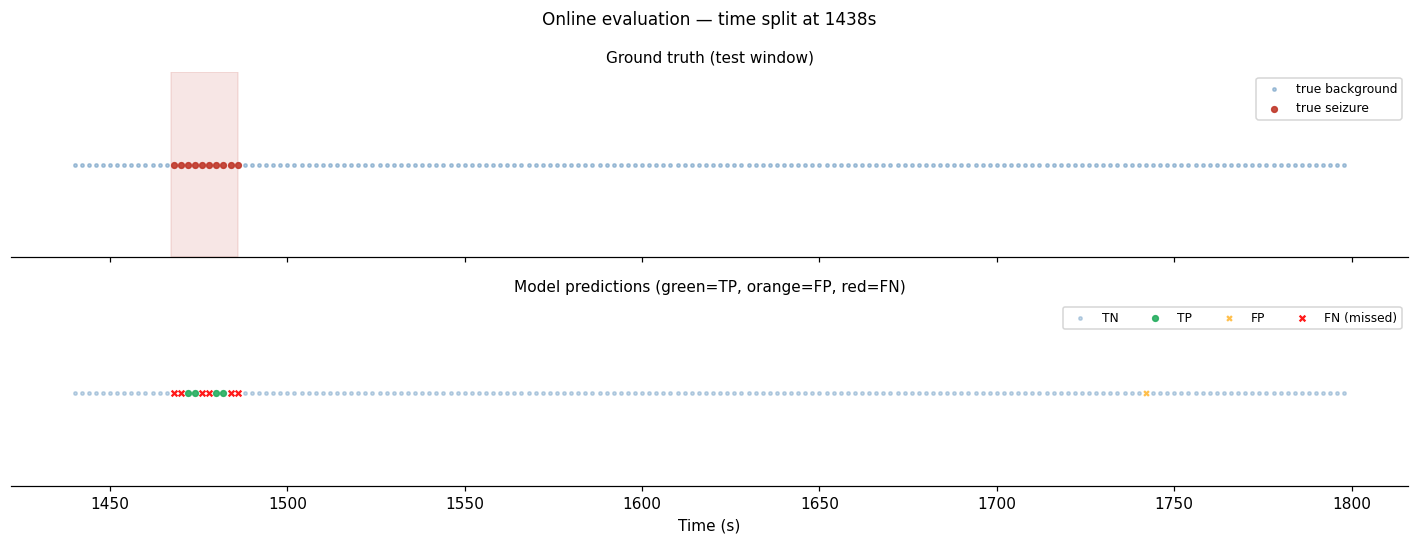

In [21]:
# Visualize predictions over time in the test window
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].scatter(t_ctr_te[y_te_t==0], np.zeros((y_te_t==0).sum()),
                c='steelblue', s=5, alpha=0.4, label='true background')
axes[0].scatter(t_ctr_te[y_te_t==1], np.zeros((y_te_t==1).sum()),
                c='#c0392b', s=14, alpha=0.9, label='true seizure')
for _, r in seiz_intervals.iterrows():
    if r['stop'] > t_cut:
        axes[0].axvspan(r['start'], r['stop'], color='#c0392b', alpha=0.12)
axes[0].set_yticks([]); axes[0].set_title('Ground truth (test window)', fontsize=10)
axes[0].legend(fontsize=8); axes[0].spines[['top','right','left']].set_visible(False)

correct   = y_pred_online == y_te_t
fp_mask   = (y_pred_online == 1) & (y_te_t == 0)
fn_mask   = (y_pred_online == 0) & (y_te_t == 1)
tp_mask   = (y_pred_online == 1) & (y_te_t == 1)
tn_mask   = (y_pred_online == 0) & (y_te_t == 0)

axes[1].scatter(t_ctr_te[tn_mask], np.zeros(tn_mask.sum()),
                c='steelblue', s=5, alpha=0.3, label='TN')
axes[1].scatter(t_ctr_te[tp_mask], np.zeros(tp_mask.sum()),
                c='#27ae60', s=14, alpha=0.9, label='TP')
axes[1].scatter(t_ctr_te[fp_mask], np.full(fp_mask.sum(), 0),
                c='orange', s=10, alpha=0.7, marker='x', label='FP')
axes[1].scatter(t_ctr_te[fn_mask], np.full(fn_mask.sum(), 0),
                c='red', s=14, alpha=0.9, marker='x', label='FN (missed)')
axes[1].set_xlabel('Time (s)'); axes[1].set_yticks([])
axes[1].set_title('Model predictions (green=TP, orange=FP, red=FN)', fontsize=10)
axes[1].legend(fontsize=8, ncol=4); axes[1].spines[['top','right','left']].set_visible(False)

plt.suptitle(f'Online evaluation — time split at {t_cut:.0f}s', fontsize=11)
plt.tight_layout(); plt.show()

---
### Questions - The Online Challenge

**Q19.** Compare the sensitivity from the random split vs. the time split for the same model. Which is higher? Why does the split strategy matter so much?

**Q20.** What is the detection latency for the seizure(s) in the test window? Is a 10-second latency clinically acceptable? What about 30 seconds? Who decides - and based on what?

**Q21.** A hospital wants to deploy this system to trigger an alert to a nurse. What threshold for the model's output probability would you choose, and how would you set it? *(Hint: there is no single right answer - frame it as a trade-off.)*

**Q22.** This recording has three seizures: at ~322 s, ~1042 s, and ~1467 s. Where does the 80% time cutoff fall exactly (`t_cut`)? Which seizures fall in the training window and which in the test window? Does the model have any seizure examples in training?

---
## Section 6b - Grad-CAM (ADVANCED): What Did the Model Learn?

The CNN is a black box: it classifies a 4-second window as seizure or background, but
gives no explanation. **Gradient-weighted Class Activation Mapping (Grad-CAM)** opens that
box by asking: *which part of the input drove this prediction?*

**Method (in one equation):**

$$\text{CAM} = \text{ReLU}\!\left(\sum_k \underbrace{\frac{1}{T}\sum_t \frac{\partial s}{\partial A^k_t}}_{\alpha_k} A^k\right)$$

- $A^k$ - feature map of filter $k$ in the last conv block (shape: 128 × 64 time steps)
- $\frac{\partial s}{\partial A^k}$ - gradient of the seizure logit $s$ w.r.t. that map
- $\alpha_k$ - importance weight for filter $k$ (global average of gradients)
- ReLU keeps only features that *increase* the seizure score

The result is a 1D saliency trace over time, upsampled to the input length.

**Per-channel importance:** input × gradient, averaged over time - tells you *which electrode*
the model is paying attention to.

In [22]:
# ── Grad-CAM implementation ───────────────────────────────────────────────────

def grad_cam_1d(model, x_window, target_class=1):
    """
    Grad-CAM saliency over time for one EEG window.
    x_window : np.array (n_ch, n_samples) — raw (unnormalized) window
    Returns   : np.array (n_samples,) in [0, 1]
    """
    model.eval()
    mu  = x_window.mean(axis=1, keepdims=True)
    std = x_window.std(axis=1, keepdims=True) + 1e-8
    x_t = torch.tensor(((x_window - mu) / std).astype(np.float32)).unsqueeze(0).to(DEVICE)

    # Run encoder up to block-3 ReLU (encoder[:11]); retain gradient on that map
    # Architecture: [Conv BN ReLU Pool] x2 → [Conv BN ReLU] → AdaptiveAvgPool
    # encoder[10] = ReLU after block-3 conv  →  output shape (1, 128, 64)
    feat = model.encoder[:11](x_t)   # (1, 128, 64)
    feat.retain_grad()
    logits = model.classifier(model.encoder[11](feat))  # complete forward

    model.zero_grad()
    logits[0, target_class].backward()

    A     = feat.detach()                          # (1, 128, 64)
    G     = feat.grad                              # (1, 128, 64)
    alpha = G.mean(dim=2, keepdim=True)            # (1, 128, 1)  — filter weights
    cam   = torch.relu((alpha * A).sum(dim=1)).squeeze(0)  # (64,)

    cam_up = torch.nn.functional.interpolate(
        cam.unsqueeze(0).unsqueeze(0), size=x_window.shape[1],
        mode='linear', align_corners=False
    ).squeeze().cpu().numpy()

    vmin, vmax = cam_up.min(), cam_up.max()
    return (cam_up - vmin) / (vmax - vmin + 1e-8)


def channel_importance(model, x_window, target_class=1):
    """
    Per-channel saliency: mean |input × gradient| over time.
    Returns : np.array (n_ch,)
    """
    model.eval()
    mu  = x_window.mean(axis=1, keepdims=True)
    std = x_window.std(axis=1, keepdims=True) + 1e-8
    x_t = torch.tensor(((x_window - mu) / std).astype(np.float32)).unsqueeze(0).to(DEVICE)
    x_t.requires_grad_(True)

    logits = model(x_t)
    model.zero_grad()
    logits[0, target_class].backward()

    sal = (x_t.grad * x_t).abs().squeeze(0).mean(dim=1)   # (n_ch,)
    return sal.detach().cpu().numpy()


@torch.no_grad()
def seizure_probs(model, X_np):
    """Seizure probability (softmax class-1) for a batch of windows."""
    model.eval().to(DEVICE)
    mu  = X_np.mean(axis=2, keepdims=True)
    std = X_np.std(axis=2, keepdims=True) + 1e-8
    X_sc = torch.tensor(((X_np - mu) / std).astype(np.float32)).to(DEVICE)
    return torch.softmax(model(X_sc), dim=1)[:, 1].cpu().numpy()


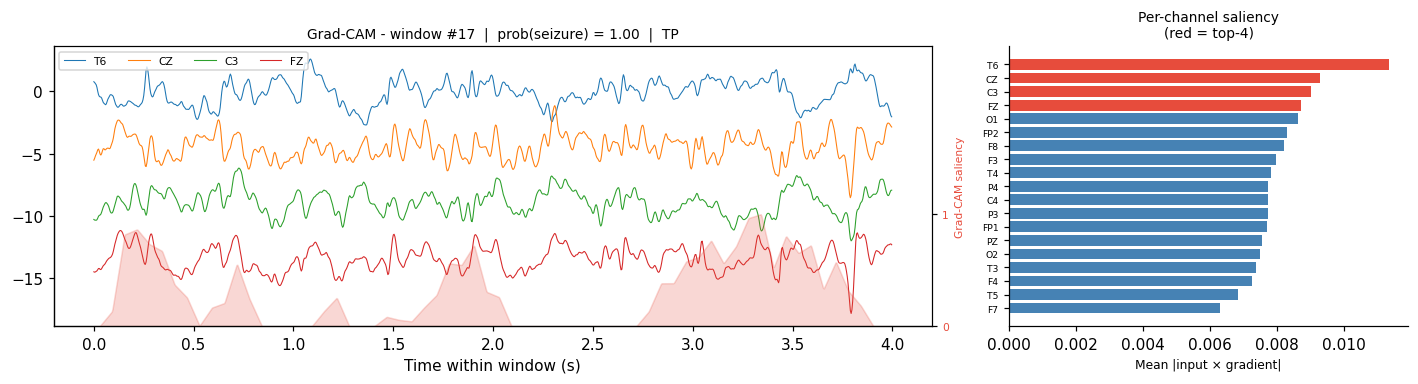

In [23]:
# ── Grad-CAM on the single most confident TUSZ seizure detection (cnn_online) ─
probs_te = seizure_probs(cnn_online, X_te_t)

# Most-confident true-seizure window (fallback: highest-prob window of any class)
true_pos = np.where(y_te_t == 1)[0]
wi = int(true_pos[np.argmax(probs_te[true_pos])]) if len(true_pos) else int(np.argmax(probs_te))

win        = X_te_t[wi]
cam        = grad_cam_1d(cnn_online, win, target_class=1)
ch_imp     = channel_importance(cnn_online, win, target_class=1)
top_ch_idx = np.argsort(ch_imp)[::-1][:4]      # four most important channels
t_win      = np.arange(WIN_SAMP) / sfreq

fig, (ax, axb) = plt.subplots(1, 2, figsize=(13, 3.6),
                              gridspec_kw={'width_ratios': [2.2, 1]})

# Left: top-4 channels (z-scored, offset) with Grad-CAM saliency overlay
for k, ci in enumerate(top_ch_idx):
    trace = win[ci] / (win[ci].std() + 1e-8)
    label = eeg_chs[ci].replace('EEG ', '').replace('-REF', '')
    ax.plot(t_win, trace - k * 4.5, lw=0.7, color=f'C{k}', label=label)
ax2 = ax.twinx()
ax2.fill_between(t_win, cam, color='#e74c3c', alpha=0.22)
ax2.set_ylim(0, 2.5); ax2.set_yticks([0, 1])
ax2.set_ylabel('Grad-CAM saliency', fontsize=7, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c', labelsize=7)
lbl = 'TP' if y_te_t[wi] == 1 else 'FP'
ax.set_title(f'Grad-CAM - window #{wi}  |  prob(seizure) = {probs_te[wi]:.2f}  |  {lbl}',
             fontsize=9)
ax.set_xlabel('Time within window (s)')
ax.legend(fontsize=7, loc='upper left', ncol=4)
ax.spines[['top', 'right']].set_visible(False)

# Right: per-channel importance bar chart
order  = np.argsort(ch_imp)
labels = [eeg_chs[i].replace('EEG ', '').replace('-REF', '') for i in order]
colors = ['#e74c3c' if i in top_ch_idx else 'steelblue' for i in order]
axb.barh(range(len(ch_imp)), ch_imp[order], color=colors, edgecolor='none')
axb.set_yticks(range(len(ch_imp))); axb.set_yticklabels(labels, fontsize=6)
axb.set_xlabel('Mean |input × gradient|', fontsize=8)
axb.set_title('Per-channel saliency\n(red = top-4)', fontsize=9)
axb.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
### Questions - Grad-CAM

**Q19b.** Look at the Grad-CAM saliency trace. Does the model's attention peak *during* the
seizure segment, or earlier/later? What would it mean if saliency peaks at the very start vs.
at the end of a flagged window?

**Q19c.** Look at the per-channel importance bar chart. Are the most-attended channels
anatomically consistent with what you would expect for a complex partial seizure (temporal lobe)?
What would unexpected channels (e.g., high frontal weight for a temporal seizure) suggest about
what the model has actually learned?

**Q19d.** The model was trained with oversampling (WeightedRandomSampler balancing the classes).
Could this change *what* the CNN learned to respond to, compared to training on the raw imbalanced
dataset? How would you test this with Grad-CAM?

**Q19e.** Grad-CAM shows *which part of the input* mattered  but not *why* that feature predicts
seizure. Name one scenario where a high-saliency region would be a genuine seizure feature, and
one where it would be a confound (something correlated with seizures in the training data, but not
causally related to them).

In [24]:
# ── Train CNN on multi-patient data ──────────────────────────────────────────
# This model has seen gnsz AND fnsz examples — we will compare it to cnn_online
# (single-patient, fnsz only) on a held-out 4th patient in Section 7.
#
# Note: no random-split eval here. X_raw_multi pools windows from 3 patients with
# 50% overlap (Q5) - a random split would put overlapping AND same-patient windows
# in both train and test, the leakage problem Section 6 raised, two ways at once.
# The only fair test of multi-patient generalization is a patient never seen
# during training - that is exactly what Section 7 does next, so we train on
# all pooled windows here and evaluate there.
print('Training CNN on multi-patient dataset (all 3 patients, no internal split) ...')
loader_tr_m = make_raw_loader(X_raw_multi, y_multi, oversample=True)

cnn_multi = EEGNet1D(n_ch_common, WIN_SAMP).to(DEVICE)
opt_m = torch.optim.Adam(cnn_multi.parameters(), lr=5e-4, weight_decay=1e-4)
for ep in range(50):
    cnn_multi.train()
    for xb, yb in loader_tr_m:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_m.zero_grad()
        loss_fn_cnn(cnn_multi(xb), yb).backward()
        opt_m.step()

print('Done. cnn_multi is evaluated on the held-out patient in Section 7.')

Training CNN on multi-patient dataset (all 3 patients, no internal split) ...
Done. cnn_multi is evaluated on the held-out patient in Section 7.


---
## Section 7 - Generalization: A Different Patient

So far we trained and tested on the **same patient**. In practice, a deployed model must work on patients it has never seen.

We now apply the best model (CNN, ICA-cleaned, time-split trained) to a **held-out patient** from the TUSZ dev set. There is no ground truth to tune on - just like a real deployment. We inspect the predictions and reason about what the model might have learned.

In [25]:
# Held-out patient: aaaaamnd, session 7, token 3
# 18 min, 256 Hz, 1 generalized seizure at ~331 s (gnsz — different type from training)
NEW_PATIENT = 'aaaaamnd'
NEW_SESSION = 's007_2012'
NEW_BNAME   = 'aaaaamnd_s007_t003'
NEW_EDF = os.path.join(TUSZ_ROOT, 'dev', NEW_PATIENT, NEW_SESSION, MONTAGE, NEW_BNAME + '.edf')
NEW_CSV = os.path.join(TUSZ_ROOT, 'dev', NEW_PATIENT, NEW_SESSION, MONTAGE, NEW_BNAME + '.csv')

raw2    = mne.io.read_raw_edf(NEW_EDF, preload=True)
seiz2   = read_tusz_csv(NEW_CSV)
ch02    = seiz2['channel'].iloc[0]
seiz2_intervals = seiz2[seiz2['channel']==ch02][seiz2['label']!='bckg'][['start','stop','label']]

print(f'New patient: {NEW_BNAME}')
print(f'Duration: {raw2.times[-1]:.0f}s  Channels: {len(raw2.ch_names)}  Rate: {raw2.info["sfreq"]}Hz')
print('\nSeizure intervals:')
for _, r in seiz2_intervals.iterrows():
    print(f"  {r['label']}  {r['start']:.0f}s – {r['stop']:.0f}s  ({r['stop']-r['start']:.0f}s)")

New patient: aaaaamnd_s007_t003
Duration: 1085s  Channels: 34  Rate: 256.0Hz

Seizure intervals:
  gnsz  331s – 400s  (69s)


In [26]:
# Preprocess new patient identically
raw2_filt = raw2.copy().filter(l_freq=0.5, h_freq=70.0, verbose=False)
raw2_filt.notch_filter(freqs=60.0, verbose=False)

# Use only the EEG channels that exist in this recording AND were in the training data
# Preserve training channel order (eeg_chs) rather than the new patient's EDF order
eeg2_chs  = [c for c in eeg_chs if c in raw2_filt.ch_names]
missing   = [c for c in eeg_chs if c not in raw2_filt.ch_names]
extra     = [c for c in raw2_filt.ch_names if c in eeg_chs and c not in eeg2_chs]
print(f'Channels in common: {len(eeg2_chs)}')
if missing: print(f'Missing (in train, not in new patient): {missing}')

raw2_ica_in = raw2_filt.copy().pick(eeg2_chs)
raw2_ica_in.set_channel_types({ch: 'eeg' for ch in raw2_ica_in.ch_names})
raw2_ica_ref = raw2_ica_in.copy().set_eeg_reference('average', projection=True, verbose=False)
raw2_ica_ref.apply_proj()

ica2 = _ICA(n_components=15, method='fastica', random_state=SEED, max_iter=1000)
ica2.fit(raw2_ica_ref, verbose=False)
fp2 = [c for c in raw2_ica_ref.ch_names if 'FP1' in c or 'FP2' in c]
eog2, _ = ica2.find_bads_eog(raw2_ica_ref, ch_name=fp2, verbose=False)
ica2.exclude = eog2
raw2_clean = ica2.apply(raw2_ica_ref.copy(), verbose=False)

data2    = raw2_clean.get_data() * 1e6
n2_samp  = data2.shape[1]
starts2  = np.arange(0, n2_samp - WIN_SAMP + 1, HOP_SAMP)
X2_raw   = np.stack([data2[:, i0: i0 + WIN_SAMP] for i0 in starts2])

# If channel count differs, pad with zeros for missing channels
if X2_raw.shape[1] < n_eeg_ch:
    pad = np.zeros((len(starts2), n_eeg_ch - X2_raw.shape[1], WIN_SAMP))
    X2_raw = np.concatenate([X2_raw, pad], axis=1)

print(f'\nInference windows: {len(starts2)}')

y2_pred = predict_raw(cnn_online, X2_raw)
y2_true = label_windows(starts2, WIN_SAMP, raw2.info['sfreq'], seiz2_intervals)
metrics_new = eval_report(y2_true, y2_pred, 'CNN / single-patient / held-out patient')

# Multi-patient model — trained on gnsz + fnsz across 3 patients
y2_pred_m = predict_raw(cnn_multi, X2_raw)
metrics_new_m = eval_report(y2_true, y2_pred_m, 'CNN / multi-patient  / held-out patient')

Channels in common: 19

Inference windows: 541

── CNN / single-patient / held-out patient ──
  Accuracy    : 0.937
  Sensitivity : 0.000  (true positive rate — seizures correctly detected)
  Specificity : 1.000  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   507       0]  True 0 (background)
  [    34       0]  True 1 (seizure)

── CNN / multi-patient  / held-out patient ──
  Accuracy    : 0.941
  Sensitivity : 0.765  (true positive rate — seizures correctly detected)
  Specificity : 0.953  (true negative rate — background correctly rejected)
  Confusion matrix:
    Pred 0  Pred 1
  [   483      24]  True 0 (background)
  [     8      26]  True 1 (seizure)


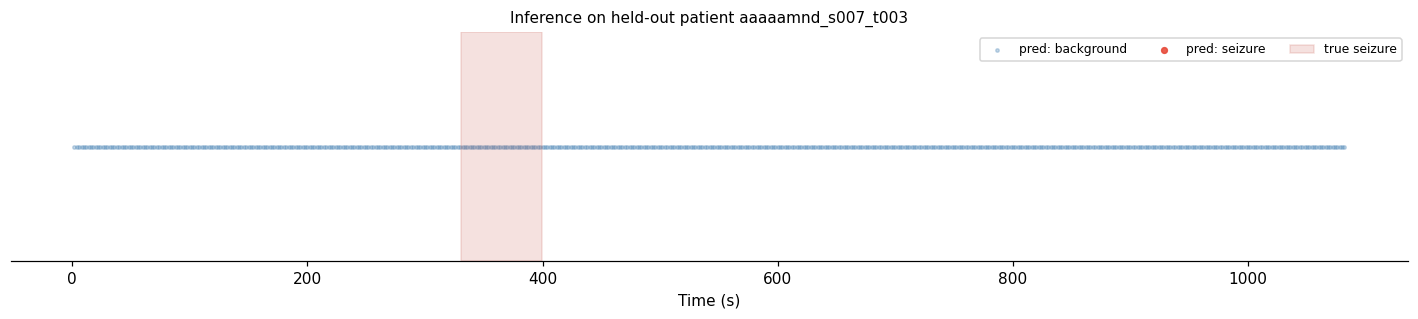

In [27]:
t2_ctr = (starts2 + WIN_SAMP // 2) / raw2.info['sfreq']
fig, ax = plt.subplots(figsize=(13, 3))
ax.scatter(t2_ctr[y2_pred==0], np.zeros((y2_pred==0).sum()),
           c='steelblue', s=5, alpha=0.3, label='pred: background')
ax.scatter(t2_ctr[y2_pred==1], np.zeros((y2_pred==1).sum()),
           c='#e74c3c', s=14, alpha=0.9, label='pred: seizure')
for _, r in seiz2_intervals.iterrows():
    ax.axvspan(r['start'], r['stop'], color='#c0392b', alpha=0.15, label='true seizure')
ax.set_xlabel('Time (s)'); ax.set_yticks([])
ax.set_title(f'Inference on held-out patient {NEW_BNAME}', fontsize=10)
ax.legend(fontsize=8, ncol=3); ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout(); plt.show()

---
### Questions - Generalization

**Q23.** Compare sensitivity on the held-out patient vs. the same-patient time-split. How much does performance drop? What are the main sources of patient-to-patient variability that could explain this?

**Q24.** The two patients are both from the same TUH dataset, recorded with the same equipment. If you instead tested on the Yobe hospital EEG (different country, different EEG machine, 50 Hz vs 60 Hz line noise), what additional steps would you need before running inference?

**Q25.** One strategy for improving generalization is **leave-one-patient-out cross-validation**: train on all patients except one, test on the left-out one, and repeat. Describe in pseudocode how you would implement this. What practical problem arises with TUSZ, which has hundreds of patients?

---
## Stretch Goal - Generalizing Beyond fnsz / gnsz

Both patients used above only have `fnsz` and `gnsz` seizures. Four more types are available locally, added for this exercise (see *"TUSZ Patients Used in This Workshop"* in the workshop support slides):

| Patient | Type(s) | Montage |
|---|---|---|
| `aaaaaict` | `cpsz` - focal, impaired awareness | `01_tcp_ar` |
| `aaaaaoek` | `tcsz`, `tnsz` - generalized tonic-clonic / tonic | `01_tcp_ar` |
| `aaaaaazz` | `absz` - generalized absence | `02_tcp_le` $^\dagger$ |

$^\dagger$ linear-ear montage - channel suffix is `-LE`, not `-REF`; adjust the channel-renaming step if you load it directly.

**Try it:**
- Build windows + labels for one or more of these patients - reuse `read_tusz_csv`, `merge_seizure_intervals`, and `label_windows` from Sections 1-2, just point `EDF_PATH`/`CSV_PATH` at a new patient (paths below).
- Add them to the multi-patient training set (`cnn_multi`). Does sensitivity on `fnsz`/`gnsz` improve, hold steady, or degrade?
- Hold one type out entirely (e.g. train with no `tcsz` windows at all) and test on it. Can the model detect a seizure type it has never seen? This tests true generalization, not memorized morphology.
- Report **sensitivity per type**, not one aggregate number - a model that looks 95% sensitive overall could be 0% sensitive on `absz` alone (very different morphology from `fnsz`/`gnsz` - see the lecture's seizure type gallery figure).

In [28]:
NEW_PATIENTS = {
    'cpsz': dict(patient='aaaaaict', session='s003_2011', bname='aaaaaict_s003_t000', montage='01_tcp_ar'),
    'tcsz': dict(patient='aaaaaoek', session='s004_2013', bname='aaaaaoek_s004_t001', montage='01_tcp_ar'),
    'tnsz': dict(patient='aaaaaoek', session='s004_2013', bname='aaaaaoek_s004_t004', montage='01_tcp_ar'),
    'absz': dict(patient='aaaaaazz', session='s001_2003', bname='aaaaaazz_s001_t001', montage='02_tcp_le'),
}

for sz_type, info in NEW_PATIENTS.items():
    edf = os.path.join(TUSZ_ROOT, 'dev', info['patient'], info['session'], info['montage'],
                        info['bname'] + '.edf')
    print(f"{sz_type:6s} {info['patient']:10s} exists: {os.path.exists(edf)}")

cpsz   aaaaaict   exists: True
tcsz   aaaaaoek   exists: True
tnsz   aaaaaoek   exists: True
absz   aaaaaazz   exists: True


---
## Stretch Goal - Pre-ictal Changes

So far we classified **seizure vs. background**. A harder and clinically more valuable question: can we detect that a seizure is **about to happen** - before it starts?

Re-label the data:
- `1 (pre-ictal)` - windows in the 30 minutes **before** each seizure onset
- `0 (inter-ictal)` - windows far from any seizure (>30 min away from onset or offset)

Then train the same models on this new problem.

In [29]:
PRE_ICTAL_S = 30 * 60   # 30 minutes
MARGIN_S    = 5 * 60    # exclude windows within 5 min of seizure end (post-ictal)

def label_preilctal(starts, win_samp, sfreq, seiz_intervals, pre_s=1800, margin_s=300):
    y_pi = np.full(len(starts), -1, dtype=int)   # -1 = ambiguous, exclude
    win_s = win_samp / sfreq
    for wi, i0 in enumerate(starts):
        t_ctr = (i0 + win_samp / 2) / sfreq
        is_pre = False
        is_ambiguous = False
        for _, r in seiz_intervals.iterrows():
            if r['start'] - pre_s <= t_ctr < r['start']:
                is_pre = True
            if r['start'] - pre_s - margin_s <= t_ctr < r['start'] or \
               r['stop'] <= t_ctr <= r['stop'] + margin_s:
                is_ambiguous = True
        if is_pre:
            y_pi[wi] = 1
        elif not is_ambiguous:
            y_pi[wi] = 0
    return y_pi

y_pi = label_preilctal(starts, WIN_SAMP, sfreq, seiz_intervals)
keep = y_pi >= 0
print(f'Pre-ictal windows  : {(y_pi==1).sum()}')
print(f'Inter-ictal windows: {(y_pi==0).sum()}')
print(f'Excluded (ambiguous): {(y_pi==-1).sum()}')
print()
print('Try training the MLP on X_bp[keep] with labels y_pi[keep].')
print('Does any EEG feature change in the 30 minutes before seizure onset?')

Pre-ictal windows  : 733
Inter-ictal windows: 16
Excluded (ambiguous): 150

Try training the MLP on X_bp[keep] with labels y_pi[keep].
Does any EEG feature change in the 30 minutes before seizure onset?


---
### Questions - Pre-ictal

**Q26.** How many pre-ictal windows do you get from this single 30-minute recording? Is that enough to train a reliable classifier? What would you need to do to get more?

**Q27.** Train the MLP on the pre-ictal labels. Which frequency band shows the largest difference between pre-ictal and inter-ictal windows? Look at EEG_01's band-power plots - does this match what you saw there?

**Q28.** Pre-ictal prediction is an unsolved problem in epilepsy research. Name two reasons why it is fundamentally harder than ictal detection - beyond just having fewer labelled examples.

---
## Section 8 - The Real Test: No Labels, No Benchmark

So far every evaluation had a safety net: a ground-truth annotation file you could check against.

Now that safety net is gone.

Below is a de-identified EEG recording from Yobe State University Teaching Hospital (YSUTH),
Nigeria (~24 minutes, 43 channels, 500 Hz). **You have the signal only.** There is no
machine-readable annotation file, and we do not have a narrative clinical report for it either.
We genuinely do not know whether, or where, this recording contains a seizure.

That is the normal situation in a clinic with no automated detector: a raw recording arrives with
no labels, and a human has to decide what is in it. Your job here is not to "find the seizure" -
it is to deploy the model the way you would in the field and then reason honestly about what its
output is worth when you have nothing to check it against.

One caution before you start: in Section 7, `cnn_online` (trained on a single patient) scored
**0% sensitivity** on a held-out TUSZ patient - it generalized to no one. `cnn_multi` (trained on
three patients) recovered to about 0.76 sensitivity on that same patient. So if `cnn_online` is
silent here, that is its known failure mode, not evidence that the recording is seizure-free. We
run both models below so the deployment test includes a model that can actually generalize.

Your task:
1. Preprocess the recording (note: Nigerian mains = **50 Hz**, not 60 Hz)
2. Run both trained CNNs - `cnn_online` (one patient) and `cnn_multi` (three patients) - the way you would "deploy" them
3. Reason from the output: what can you trust, and what can you not claim?

**There are no code-answer questions in this section. The questions require written reasoning.**

> **Instructor note:** A normalized broadband-power topomap animation of this recording is in the course data
> folder at `Data/YSUTH/yobe_topomap.mp4`. It shows one or more large, broadband power surges spread
> across essentially all channels at once. That all-channel, broadband pattern is characteristic
> of movement or muscle artifact, not of a focal seizure (which would start in a few channels and
> evolve in frequency). Notably `cnn_online` does **not** flag it (max probability 0.008), and we
> also run `cnn_multi` (the model that did generalize in Section 7) for comparison.
> Showing the video next to the model output is a good way to discuss what an artifact looks like,
> why a naive viewer might mistake it for a seizure, and what "no detection" does and does not prove.

In [30]:
import os

# ── Data path ─────────────────────────────────────────────────────────────────
# SUBJECT1.edf is the real YSUTH (Yobe) recording. Its EDF header is anonymized
# (patient field 'X X X X'); it ships in the course data folder under YSUTH/.
# On Colab the bootstrap cell downloads it to YSUTH/SUBJECT1.edf. We load the
# SIGNAL ONLY and never read an annotation file: this section is inference with
# no ground truth. If the file is missing we fall back to a held-out TUSZ
# recording (labels not loaded) purely so the code runs end-to-end.

_YSUTH_CANDIDATES = [
    'YSUTH/SUBJECT1.edf',                                  # Colab download / repo-relative
    os.path.join('..', 'Data', 'YSUTH', 'SUBJECT1.edf'),
    os.path.expanduser('~/Library/CloudStorage/OneDrive-UAB/Projectes/'
                       'BioRTC-Simons_NIGERIA/Materials/T8/SUBJECT1.edf'),  # local working copy
]
YOBE_EDF  = next((p for p in _YSUTH_CANDIDATES if os.path.exists(p)), None)
USE_PROXY = YOBE_EDF is None

if USE_PROXY:
    # Fallback: a held-out TUSZ recording. We do NOT load its CSV labels, so it
    # is treated exactly like the Yobe file - an unlabeled recording to reason about.
    PROXY_BNAME = 'aaaaamnd_s007_t003'
    PROXY_SESSION = 's007_2012'
    YOBE_EDF = os.path.join(TUSZ_ROOT, 'dev', 'aaaaamnd', PROXY_SESSION, MONTAGE,
                             PROXY_BNAME + '.edf')
    print('SUBJECT1.edf not found - using a held-out TUSZ recording (no labels loaded)')
else:
    print(f'Using YSUTH SUBJECT1.edf  ({YOBE_EDF})')

raw_y = mne.io.read_raw_edf(YOBE_EDF, preload=True, verbose=False)
print(f'Duration : {raw_y.times[-1]:.0f} s  ({raw_y.times[-1]/60:.1f} min)')
print(f'Channels : {len(raw_y.ch_names)}')
print(f'Sampling : {raw_y.info["sfreq"]} Hz')

# ── Identify EEG channels ─────────────────────────────────────────────────────
eeg_y = [c for c in raw_y.ch_names if not any(x in c for x in NON_EEG)]
print(f'EEG channels: {len(eeg_y)}')

Using YSUTH SUBJECT1.edf  (/Users/silvana/Library/CloudStorage/OneDrive-UAB/Projectes/BioRTC-Simons_NIGERIA/Materials/T8/SUBJECT1.edf)
Duration : 1452 s  (24.2 min)
Channels : 43
Sampling : 500.0 Hz
EEG channels: 37


In [31]:
# ── Preprocess — key difference: 50 Hz notch (Nigerian mains, not 60 Hz) ─────
raw_y_filt = raw_y.copy().filter(l_freq=0.5, h_freq=70.0, verbose=False)
raw_y_filt.notch_filter(freqs=50.0, verbose=False)   # ← 50 Hz, not 60 Hz

# Resample to match training sampling rate (answers Q3: must match WIN_SAMP temporal scale)
TRAIN_SFREQ = int(sfreq)   # 256 Hz — defined when training data was loaded
if int(raw_y_filt.info['sfreq']) != TRAIN_SFREQ:
    print(f'Resampling {raw_y_filt.info["sfreq"]:.0f} Hz → {TRAIN_SFREQ} Hz  '
          f'(CNN expects {WIN_SAMP} samples = {WIN_SAMP/TRAIN_SFREQ:.1f} s per window)')
    raw_y_filt.resample(sfreq=TRAIN_SFREQ, verbose=False)
else:
    print(f'Sampling rate already {TRAIN_SFREQ} Hz — no resampling needed')

# ── Channel matching with name normalization ──────────────────────────────────
# Training channels (TUSZ): 'EEG FP1-REF'; Nihon Kohden may use 'EEG Fp1-Ref' or 'Fp1'
import re as _re

def _norm_ch(name):
    """Bare electrode name: strip 'EEG ' prefix and '-REF'/'-LE'/'-AR' suffix."""
    name = _re.sub(r'^EEG\s+', '', name, flags=_re.IGNORECASE)
    name = _re.sub(r'[-_\s](REF|LE|AR)$', '', name, flags=_re.IGNORECASE)
    return name.upper().strip()

_train_norm   = {_norm_ch(c): c for c in eeg_chs}     # 'FP1' → 'EEG FP1-REF'
eeg_y_to_train = {c: _train_norm[_norm_ch(c)]
                  for c in eeg_y if _norm_ch(c) in _train_norm}

eeg_y_common = list(eeg_y_to_train.keys())
missing_y    = [tc for tc in eeg_chs if tc not in eeg_y_to_train.values()]
print(f'Channels matched to training set : {len(eeg_y_common)}')
if missing_y:
    print(f'Missing (will be zero-padded)    : {len(missing_y)} channels')
if not eeg_y_common:
    print(f'  Yobe ch sample    : {eeg_y[:6]}')
    print(f'  Training ch sample: {eeg_chs[:6]}')
    raise RuntimeError('No channels matched — check naming above.')

# ICA — same pipeline as training
raw_y_ica = raw_y_filt.copy().pick(eeg_y_common)
raw_y_ica.rename_channels(eeg_y_to_train)   # standardize to training-style names
raw_y_ica.set_channel_types({c: 'eeg' for c in raw_y_ica.ch_names})
raw_y_ref = raw_y_ica.copy().set_eeg_reference('average', projection=True, verbose=False)
raw_y_ref.apply_proj()

ica_y = _ICA(n_components=min(15, len(eeg_y_common) - 1), method='fastica',
             random_state=SEED, max_iter=1000)
ica_y.fit(raw_y_ref, verbose=False)
fp_y = [c for c in raw_y_ref.ch_names if 'FP1' in c or 'FP2' in c]
if fp_y:
    eog_y, _ = ica_y.find_bads_eog(raw_y_ref, ch_name=fp_y, verbose=False)
    ica_y.exclude = eog_y
raw_y_clean = ica_y.apply(raw_y_ref.copy(), verbose=False)

# ── Window — channels ordered to match training layout (missing → zero) ───────
data_y   = raw_y_clean.get_data() * 1e6
starts_y = np.arange(0, data_y.shape[1] - WIN_SAMP + 1, HOP_SAMP)
ch_to_row = {ch: i for i, ch in enumerate(raw_y_clean.ch_names)}
X_y = np.zeros((len(starts_y), n_eeg_ch, WIN_SAMP), dtype=np.float32)
for ci, ch in enumerate(eeg_chs):
    if ch in ch_to_row:
        row = data_y[ch_to_row[ch]]
        for wi, i0 in enumerate(starts_y):
            X_y[wi, ci] = row[i0: i0 + WIN_SAMP]

t_y = (starts_y + WIN_SAMP // 2) / raw_y_clean.info['sfreq']
print(f'\nWindows for inference: {len(starts_y)}')
print('No annotation file loaded. Ground truth is unknown.')


Resampling 500 Hz → 256 Hz  (CNN expects 1024 samples = 4.0 s per window)
Channels matched to training set : 19

Windows for inference: 725
No annotation file loaded. Ground truth is unknown.


cnn_online (1 patient)    flagged   0 / 725 windows ( 0.0%)   max P(seizure) = 0.008
cnn_multi (3 patients)    flagged  51 / 725 windows ( 7.0%)   max P(seizure) = 1.000

Reading this honestly:
  - cnn_online scored 0% sensitivity on a held-out TUSZ patient (Section 7).
    Its silence here is its known failure mode, NOT evidence of "no seizure".
  - cnn_multi flags windows at high confidence. It generalized within TUSZ, but this
    Yobe recording is out-of-distribution and unlabeled: those detections may be real,
    or the model firing on artifact / domain shift. Confidence is not correctness.


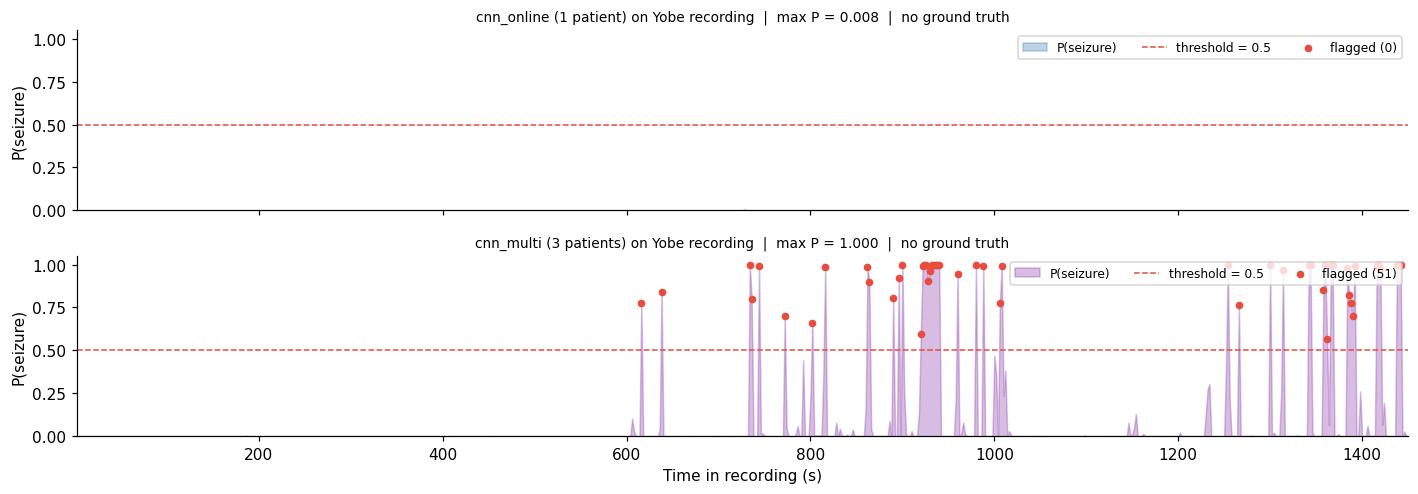

In [32]:
# ── Deploy BOTH models on the Yobe recording - no labels to compare against ──
# Section 7 established that cnn_online (one patient) scored 0% sensitivity on a
# held-out TUSZ patient: it generalizes to no one. cnn_multi (three patients)
# recovered ~0.76 sensitivity on that same patient. We run both here: a model
# that already failed to generalize, and one that did.
models = [('cnn_online (1 patient)', cnn_online, 'steelblue'),
          ('cnn_multi (3 patients)', cnn_multi,  '#8e44ad')]

results = {}
for name, model, _ in models:
    p  = seizure_probs(model, X_y)
    pr = (p >= 0.5).astype(int)
    results[name] = (p, pr)
    print(f'{name:24s}  flagged {int(pr.sum()):3d} / {len(p)} windows '
          f'({100 * pr.sum() / len(p):4.1f}%)   max P(seizure) = {p.max():.3f}')

print()
print('Reading this honestly:')
print('  - cnn_online scored 0% sensitivity on a held-out TUSZ patient (Section 7).')
print('    Its silence here is its known failure mode, NOT evidence of "no seizure".')
print('  - cnn_multi flags windows at high confidence. It generalized within TUSZ, but this')
print('    Yobe recording is out-of-distribution and unlabeled: those detections may be real,')
print('    or the model firing on artifact / domain shift. Confidence is not correctness.')

# ── Timeline plot: both models stacked ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 4.6), sharex=True)
for ax, (name, model, color) in zip(axes, models):
    p, pr = results[name]
    ax.fill_between(t_y, p, alpha=0.35, color=color, label='P(seizure)')
    ax.axhline(0.5, color='#e74c3c', lw=1, ls='--', label='threshold = 0.5')
    ax.scatter(t_y[pr == 1], p[pr == 1], c='#e74c3c', s=16, zorder=3,
               label=f'flagged ({int(pr.sum())})')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('P(seizure)')
    ax.set_title(f'{name} on Yobe recording  |  max P = {p.max():.3f}  |  no ground truth',
                 fontsize=9)
    ax.legend(fontsize=8, ncol=3, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
axes[-1].set_xlabel('Time in recording (s)')
axes[0].set_xlim(t_y[0], t_y[-1])
plt.tight_layout()
plt.show()

# Names kept for any later reference (cnn_online timeline)
probs_y, preds_y = results['cnn_online (1 patient)']

---
### Questions - Reasoning Without Labels

These questions require written answers. There is no code to run.

**Q29.** The model flags several windows as seizures. Without a label file, list at least
**three signal-level criteria** you would apply to decide whether a detection is credible -
criteria that do not depend on knowing the ground truth.

**Q30.** You have no annotation file and no clinical report for this recording, so there is no
ground truth to compare against. Given that, what would it actually take to verify a detection
the model makes? List the concrete evidence you would need, and from whom, before you could
state that a flagged window is a real seizure.

**Q31.** The model was trained on a US hospital dataset (Temple University, 60 Hz mains).
List at least **two recording-level differences** between that training data and this Yobe
recording that could cause a deployed model to fire on non-seizure activity. If the model
*did* flag a window here, how would the Grad-CAM tool from Section 6b help you decide whether
the detection was a real seizure feature or an artifact?

**Q32.** You corrected for 50 Hz line noise instead of 60 Hz. Suppose you forgot and used
`notch_filter(60)` on a 50 Hz recording. What would remain in the signal? How would this
show up in the Grad-CAM (and what would it tell you about the false positive rate)?

**Q33.** This recording contains at least one large, broadband power surge that appears on
essentially all channels at once. Why is that pattern more consistent with movement or muscle
artifact than with a focal seizure? Does *either* model flag it - and what would it mean for a
model (not for the patient) if it did?

**Q34.** Imagine you are presenting these results to Dr. Raji at YSUTH. Write
2-3 sentences: (a) what you can claim, (b) what you cannot claim, and (c) what additional
data or steps would be needed to make a stronger clinical statement.